# LiMatch Combined Diagnostic — Multi-scénarios

Structure par scénario : trajectoires, dossier LAS, fichiers LiDAR_p2p, O3d.

In [4]:
# ============================================================
# CELL 0 — Imports
# ============================================================
import sys, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

import laspy
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

sys.path.append('/home/b085164/PDM_Romain_Defferrard/ESO-PDM')
from lib.trajectory import Trajectory
from lib.rotations import quat2dcm

print('Imports OK')

Imports OK


## CONFIG

In [5]:
# ============================================================
# CELL 1 — Paramètres globaux
# ============================================================

ORIGIN_SHIFT = [4364320.0, 511805.0, 4608625.0]
DN_CFG       = {'type': 'DN', 'originShift': ORIGIN_SHIFT}

# Nuages merged pour enrichissement scanner
MERGED_ROOT = Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/merged/ALL')
MERGED_MAX_NUM = 28000

BIN_WIDTH_S = 5
MIN_CORRES  = 5
OUTPUT_DIR  = Path('./limatch_combined_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# ============================================================
# CELL 2 — Définition des scénarios
# ============================================================
# Chaque scénario regroupe TOUT ce qui lui appartient :
#   t_start / t_end       fenetre outage
#   trajs                 liste trajectoires (une reference + targets)
#   lidar_sources         liste de dossiers LiDAR_p2p
#                         kind='consec' (F2B) ou 'cross' (S2S)
#   las_dir               dossier LAS georeferencies (optionnel)
#   o3d                   config visualisation O3d  (None = desactive)

SCENARIOS = [
    {
        'label'   : 'Outage 1 — Combined AIRINS',
        't_start' : 305120.0,
        't_end'   : 305700.0,
    
        'trajs': [
            {
                'role' : 'reference',
                'type' : 'SBET',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/out/ODyN_CALIB.out',
                'cfg'  : {'type': 'SBET', 'timeRef': 'GPS'},
                'label': 'Reference ODyN',
                'color': '#888888',
                'ls'   : '--',
            },
            {
                'role' : 'target',
                'type' : 'DN',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/OUTAGE/out/ODyN.tar.gz',
                'cfg'  : DN_CFG,
                'label': 'Outage (INS seul)',
                'color': '#E74C3C',
                'ls'   : '-',
            },
            {
                'role' : 'target',
                'type' : 'DN',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/F2B/out/ODyN.tar.gz',
                'cfg'  : DN_CFG,
                'label': 'F2B',
                'color': '#2980B9',
                'ls'   : '-',
            },
            {
                'role' : 'target',
                'type' : 'DN',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/COMBINED/out/ODyN.tar.gz',
                'cfg'  : DN_CFG,
                'label': 'Combined (F2B + S2S)',
                'color': '#27AE60',
                'ls'   : '-',
            },
            {
                'role' : 'target',
                'type' : 'DN',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/S2S/out/ODyN.tar.gz',
                'cfg'  : DN_CFG,
                'label': 'S2S',
                'color': '#27AE60',
                'ls'   : '-',
            },
        ],
    
        'lidar_sources': [
            {
                'kind' : 'consec',
                'label': 'F2B',
                'color': '#B51F1F',
                'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch_F2B_v3/'),
            },
            {
                'kind' : 'cross',
                'label': 'Combined (F2B + S2S)',
                'color': '#007480',
                'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch_F2B_v3_crossings/'),
            },
        ],

        'las_dir': Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/merged/ALL'),


    },

    {
        'label'   : 'Outage 1 — Combined APX',
        't_start' : 305200.0,
        't_end'   : 305620.0,
    
        'trajs': [
            {
                'role' : 'reference',
                'type' : 'SBET',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/base/out/CALIB_APX.out',
                'cfg'  : {'type': 'SBET', 'timeRef': 'GPS'},
                'label': 'Reference ODyN',
                'color': '#888888',
                'ls'   : '--',
            },
            {
                'role' : 'target',
                'type' : 'DN',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/OUTAGE/out/ODyN.tar.gz',
                'cfg'  : DN_CFG,
                'label': 'Outage (INS seul)',
                'color': '#E74C3C',
                'ls'   : '-',
            },
            {
                'role' : 'target',
                'type' : 'DN',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/out/ODyN.tar.gz',
                'cfg'  : DN_CFG,
                'label': 'F2B',
                'color': '#2980B9',
                'ls'   : '-',
            },
            {
                'role' : 'target',
                'type' : 'DN',
                'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/COMBINED/out/ODyN.tar.gz',
                'cfg'  : DN_CFG,
                'label': 'Combined (F2B + S2S)',
                'color': '#27AE60',
                'ls'   : '-',
            },
        ],
    
        'lidar_sources': [
            {
                'kind' : 'consec',
                'label': 'F2B',
                'color': '#B51F1F',
                'root' : Path('/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/out/'),
            },
            {
                'kind' : 'cross',
                'label': 'Combined (F2B + S2S)',
                'color': '#007480',
                'root' : Path('/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/COMBINED/out/'),
            },
        ],

        'las_dir': Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/APX/merged/ALL'),


    },

    # {
    #     'label'   : 'Outage 2 — Combined AIRINS',
    #     't_start' : 305645.0,
    #     't_end'   : 306120.0,

    #     'trajs': [
    #         {
    #             'role' : 'reference',
    #             'type' : 'SBET',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/out/ODyN_CALIB.out',
    #             'cfg'  : {'type': 'SBET', 'timeRef': 'GPS'},
    #             'label': 'Reference ODyN',
    #             'color': '#888888',
    #             'ls'   : '--',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/OUTAGE/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Outage (INS seul)',
    #             'color': '#E74C3C',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/F2B/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'F2B',
    #             'color': '#2980B9',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/COMBINED/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Combined (F2B + S2S)',
    #             'color': '#27AE60',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/S2S/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'S2S',
    #             'color': '#27AE60',
    #             'ls'   : '-',
    #         },
    #     ],

    #     'lidar_sources': [
    #         {
    #             'kind' : 'f2b',
    #             'color': '#B51F1F',
    #             'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/limatch_F2B_v2'),
    #         },
    #         {
    #             'kind' : 'crossing',
    #             'color': '#007480',
    #             'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/limatch_F2B_v2_crossings'),
    #         },
    #     ],

    #     'las_dir': Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/merged/ALL'),

    #     'o3d': {
    #         'margin_m'    : 5.0,
    #         'sbet_path'   : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/F2B_z3/out/F2B_out3_apx.out',
    #         'chunk_a'     : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_1000_VUX_PUCK/chunk_1035.las',
    #         'chunk_b'     : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_5000_VUX_PUCK/chunk_5076.las',
    #         'bbox_a_csv'  : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_1000_VUX_PUCK/chunk_bbox.csv',
    #         'bbox_b_csv'  : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_5000_VUX_PUCK/chunk_bbox.csv',
    #         'chunk_a_name': 'chunk_1035.las',
    #         'chunk_b_name': 'chunk_5076.las',
    #     },
    # },

    # {
    #     'label'   : 'Outage 2 — Combined APX',
    #     't_start' : 305645.0,
    #     't_end'   : 306120.0,

    #     'trajs': [
    #         {
    #             'role' : 'reference',
    #             'type' : 'SBET',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/base/out/CALIB_APX.out',
    #             'cfg'  : {'type': 'SBET', 'timeRef': 'GPS'},
    #             'label': 'Reference ODyN',
    #             'color': '#888888',
    #             'ls'   : '--',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/OUTAGE/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Outage (INS seul)',
    #             'color': '#E74C3C',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'F2B',
    #             'color': '#2980B9',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/COMBINED/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Combined (F2B + S2S)',
    #             'color': '#27AE60',
    #             'ls'   : '-',
    #         },
    #     ],

    #     'lidar_sources': [
    #         {
    #             'kind' : 'f2b',
    #             'color': '#B51F1F',
    #             'roots': [Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/limatch_F2B_v1')],
    #         },
    #         {
    #             'kind' : 'crossing',
    #             'color': '#007480',
    #             'roots': [
    #                 Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/limatch_polygon_v2'),
    #                 Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/limatch_polygon'),
    #                 Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/limatch_debug/9000_10000/cor_outputs'),
    #                 Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/limatch_debug/18000_19000/cor_outputs'),
    #                 Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/georef_F2B/limatch_debug/2nd/18000_19000/cor_outputs'),
    #             ],
    #         },
    #     ],

    #     'las_dir': Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/APX/merged/ALL'),

    #     'o3d': {
    #         'margin_m'    : 5.0,
    #         'sbet_path'   : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/F2B_z3/out/F2B_out3_apx.out',
    #         'chunk_a'     : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_1000_VUX_PUCK/chunk_1035.las',
    #         'chunk_b'     : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_5000_VUX_PUCK/chunk_5076.las',
    #         'bbox_a_csv'  : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_1000_VUX_PUCK/chunk_bbox.csv',
    #         'bbox_b_csv'  : '/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/scenario_combined/chunks_10m/merged_5000_VUX_PUCK/chunk_bbox.csv',
    #         'chunk_a_name': 'chunk_1035.las',
    #         'chunk_b_name': 'chunk_5076.las',
    #     },
    # },

    # # ── Ajoute un scénario en copiant/adaptant ce bloc ─────────
    # {
    #     'label'   : 'Outage 3 — Combined AIRINS',
    #     't_start' : 306290.0,
    #     't_end'   : 306645.0,
    
    #     'trajs': [
    #         {
    #             'role' : 'reference',
    #             'type' : 'SBET',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/out/ODyN_CALIB.out',
    #             'cfg'  : {'type': 'SBET', 'timeRef': 'GPS'},
    #             'label': 'Reference ODyN',
    #             'color': '#888888',
    #             'ls'   : '--',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/OUTAGE/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Outage (INS seul)',
    #             'color': '#E74C3C',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/F2B/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'F2B',
    #             'color': '#2980B9',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/COMBINED/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Combined (F2B + S2S)',
    #             'color': '#27AE60',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/S2S/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'S2S',
    #             'color': '#27AE60',
    #             'ls'   : '-',
    #         },
    #     ],
    
    #     'lidar_sources': [
    #         {
    #             'kind' : 'f2b',
    #             'color': '#B51F1F',
    #             'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_F2B_v2'),
    #         },
    #         {
    #             'kind' : 'crossing',
    #             'color': '#007480',
    #             'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_F2B_v2_crossings'),
    #         },
    #     ],

    #     'las_dir': Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/merged/ALL'),


    #     'o3d': {}

    # },
    # {
    #     'label'   : 'Outage 3 — Combined APX',
    #     't_start' : 306290.0,
    #     't_end'   : 306645.0,
    
    #     'trajs': [
    #         {
    #             'role' : 'reference',
    #             'type' : 'SBET',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/base/out/CALIB_APX.out',
    #             'cfg'  : {'type': 'SBET', 'timeRef': 'GPS'},
    #             'label': 'Reference ODyN',
    #             'color': '#888888',
    #             'ls'   : '--',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/OUTAGE/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Outage (INS seul)',
    #             'color': '#E74C3C',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/F2B/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'F2B',
    #             'color': '#2980B9',
    #             'ls'   : '-',
    #         },
    #         {
    #             'role' : 'target',
    #             'type' : 'DN',
    #             'path' : '/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/COMBINED/out/ODyN.tar.gz',
    #             'cfg'  : DN_CFG,
    #             'label': 'Combined (F2B + S2S)',
    #             'color': '#27AE60',
    #             'ls'   : '-',
    #         },
    #     ],
    
    #     'lidar_sources': [
    #         {
    #             'kind' : 'f2b',
    #             'color': '#B51F1F',
    #             'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/limatch_F2B'),
    #         },
    #         {
    #             'kind' : 'crossing',
    #             'color': '#007480',
    #             'root' : Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/georef_F2B/limatch_F2B_traj_F2B_v3_crossings'),
    #         },
    #     ],

    #     'las_dir': Path('/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/merged/ALL'),


    #     'o3d': {}

    # },
]

print(f'{len(SCENARIOS)} scenario(s) defini(s) :')
for sc in SCENARIOS:
    ns = len(sc['lidar_sources'])
    nt = len(sc['trajs'])
    print(f"  · {sc['label']}  |  {nt} trajs  |  {ns} sources LiDAR  ")

2 scenario(s) defini(s) :
  · Outage 1 — Combined AIRINS  |  5 trajs  |  2 sources LiDAR  
  · Outage 1 — Combined APX  |  4 trajs  |  2 sources LiDAR  


## Helpers

In [7]:
# ============================================================
# CELL 3 — Helpers
# ============================================================

def read_lidar_p2p_file(fp: Path) -> pd.DataFrame:
    df = pd.read_csv(fp, sep=',\\s*', engine='python', header=None)
    df = df.iloc[:, :8].copy()
    df.columns = ['t1', 't2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2']
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    return df


def load_lidar_source(src: dict, scenario_label: str) -> pd.DataFrame:
    # Supporte 'root' (Path unique) ou 'roots' (liste de Paths)
    root_list = src['roots'] if 'roots' in src else [src['root']]
    kind_lbl  = 'F2B' if src['kind'] == 'f2b' else 'S2S'

    # Deux patterns de fichiers supportés
    PATTERNS = [
        'LiDAR_p2p_chunk_*.txt',    # chunks consécutifs F2B
        'LiDAR_p2p_merged_*.txt',   # paires mergées (polygon APX)
        'LiDAR_p2p.txt',            # fichier unique (debug)
    ]

    all_files = []
    for root in root_list:
        if not root.exists():
            print(f'    ⚠ Dossier inexistant : {root}')
            continue
        for pattern in PATTERNS:
            files = list(root.rglob(pattern))
            files = [p for p in files if 'rsc' not in p.name]
            all_files.extend(files)

    # Déduplication par (nom, taille)
    seen = set()
    unique_files = []
    for fp in all_files:
        key = (fp.name, fp.stat().st_size)
        if key not in seen:
            seen.add(key)
            unique_files.append(fp)

    print(f"    [{kind_lbl}]  {len(unique_files)} fichiers "
          f"({len(all_files) - len(unique_files)} doublons exclus)")

    parts, failed = [], []
    for fp in unique_files:
        try:
            df = read_lidar_p2p_file(fp)
            if len(df) == 0:
                continue
            # Root parent pour chemin relatif
            root_parent = next(
                (r for r in root_list if fp.is_relative_to(r)),
                root_list[0]
            )
            rel    = fp.relative_to(root_parent)
            rparts = rel.parts
            merged_dir = next((x for x in rparts if x.startswith('merged_')), 'unknown')
            pair_dir   = next((x for x in rparts if '__' in x), fp.parent.name)

            df['lidar_p2p_file'] = fp.name
            df['chunk_parent']   = merged_dir
            df['pair_dir']       = pair_dir
            df['scenario']       = scenario_label
            df['source_label']   = kind_lbl
            df['source_kind']    = src['kind']
            df['p2p_dist'] = np.sqrt(
                (df['x1']-df['x2'])**2 +
                (df['y1']-df['y2'])**2 +
                (df['z1']-df['z2'])**2
            )
            df['t_mid'] = 0.5*(df['t1']+df['t2'])
            df['mx']    = 0.5*(df['x1']+df['x2'])
            df['my']    = 0.5*(df['y1']+df['y2'])
            df['mz']    = 0.5*(df['z1']+df['z2'])
            parts.append(df)
        except Exception as e:
            failed.append(f'{fp.name}: {e}')

    if failed:
        print(f'    ⚠ {len(failed)} fichiers en echec :')
        for f in failed[:5]:
            print(f'      {f}')
    if not parts:
        return pd.DataFrame()

    result = pd.concat(parts, ignore_index=True)
    print(f'    -> {len(result):,} correspondances')
    return result


def extract_merged_num(name: str) -> int:
    m = re.search(r'merged_(\d+)_', name)
    return int(m.group(1)) if m else -1

_las_cache = {}

def load_las_gps_scanner(path: str):
    if path in _las_cache:
        return _las_cache[path]
    las = laspy.read(path)
    gps = np.asarray(las['gps_time'])
    sc  = np.asarray(las['scanner_src'])
    order = np.argsort(gps)
    res = (gps[order], sc[order])
    _las_cache[path] = res
    return res


def nearest_scanner(times, gps_s, sc_s, tol=1e-6):
    pos = np.searchsorted(gps_s, times)
    out = np.full(len(times), np.nan)
    li  = np.clip(pos-1, 0, len(gps_s)-1)
    ri  = np.clip(pos,   0, len(gps_s)-1)
    dl  = np.abs(times - gps_s[li])
    dr  = np.abs(times - gps_s[ri])
    bi  = np.where(dl <= dr, li, ri)
    bd  = np.where(dl <= dr, dl, dr)
    ok  = bd <= tol
    out[ok] = sc_s[bi[ok]]
    return out


def assign_scanners(df: pd.DataFrame, merged_map: dict) -> pd.DataFrame:
    df = df.copy()
    df['scanner1_code'] = np.nan
    df['scanner2_code'] = np.nan

    # Construire un index global GPS -> scanner sur TOUS les merged
    print('    Construction index GPS global...')
    all_gps, all_sc = [], []
    for path in merged_map.values():
        try:
            gps_s, sc_s = load_las_gps_scanner(path)
            all_gps.append(gps_s)
            all_sc.append(sc_s)
        except Exception:
            pass

    if not all_gps:
        print('    ⚠ Aucun merged chargé')
        return df

    gps_global = np.concatenate(all_gps)
    sc_global  = np.concatenate(all_sc)
    order      = np.argsort(gps_global)
    gps_global = gps_global[order]
    sc_global  = sc_global[order]

    print(f'    Index global : {len(gps_global):,} points  '
          f'({gps_global.min():.1f} -> {gps_global.max():.1f})')

    # Assigner scanner1 et scanner2 en une passe sur l'index global
    t1_vals = df['t1'].to_numpy()
    t2_vals = df['t2'].to_numpy()

    df['scanner1_code'] = nearest_scanner(t1_vals, gps_global, sc_global, tol=1e-4)
    df['scanner2_code'] = nearest_scanner(t2_vals, gps_global, sc_global, tol=1e-4)

    SC = {1: 'PUCK', 2: 'VUX'}
    df['scanner1'] = df['scanner1_code'].map(SC)
    df['scanner2'] = df['scanner2_code'].map(SC)

    def pair_type(row):
        s1, s2 = row['scanner1'], row['scanner2']
        if s1 == 'VUX'  and s2 == 'VUX' : return 'VUX/VUX'
        if s1 == 'PUCK' and s2 == 'PUCK': return 'PUCK/PUCK'
        if {s1, s2} == {'VUX', 'PUCK'}  : return 'VUX/PUCK'
        return 'UNKNOWN'

    df['pair_type'] = df.apply(pair_type, axis=1)
    return df


def load_traj(entry: dict, t_grid: np.ndarray) -> Trajectory:
    if entry['type'] == 'SBET':
        trj = Trajectory.fromSBET(entry['path'], entry['cfg'])
    else:
        trj = Trajectory.fromDN(entry['path'], entry['cfg'])
    trj.label = entry['label']

    # Interpolation robuste : np.interp ne tronque pas, extrapole par les bords
    t_src = trj.time
    trj._ecef_on_grid = np.column_stack([
        np.interp(t_grid, t_src, trj.ecef[:, i])
        for i in range(3)
    ])
    trj._t_grid = t_grid

    # interp interne clippée pour q / q_l2e (évite les erreurs hors plage)
    t_clipped = np.clip(t_grid, t_src[0], t_src[-1])
    trj.interp(t_clipped, updateSelf=True)
    trj.estimate_q_l2e(interp=True)
    return trj


def planim_error(trj, ref):
    # utilise _ecef_on_grid → taille identique garantie pour tous
    e_trj = getattr(trj, '_ecef_on_grid', trj.ecef)
    e_ref = getattr(ref, '_ecef_on_grid', ref.ecef)
    dx = e_trj[:, 0] - e_ref[:, 0]
    dy = e_trj[:, 1] - e_ref[:, 1]
    return np.sqrt(dx**2 + dy**2)


def bin_temporal(df, t_start, t_end, bw):
    bins   = np.arange(t_start, t_end+bw, bw)
    labels = bins[:-1] + bw/2
    sub = df[(df['t_mid']>=t_start)&(df['t_mid']<=t_end)].copy()
    sub['bin'] = pd.cut(sub['t_mid'], bins=bins, labels=labels).astype(float)
    stats = sub.groupby('bin', observed=True).agg(
        count=('p2p_dist','count'),
        mean_p2p=('p2p_dist','mean'),
    ).reset_index()
    all_b = pd.DataFrame({'bin': labels})
    stats = all_b.merge(stats, on='bin', how='left')
    stats['count'] = stats['count'].fillna(0).astype(int)
    return stats


print('Helpers OK')

Helpers OK


## Chargement de tous les scénarios

In [8]:
# ============================================================
# CELL 4 — Index des nuages merged PAR SCÉNARIO
# ============================================================

def build_merged_map(las_dir: Path, max_num: int = 999999) -> dict:
    files = sorted(
        las_dir.glob('merged_*_VUX_PUCK.las'),
        key=lambda p: extract_merged_num(p.name)
    )
    files = [p for p in files if extract_merged_num(p.name) <= max_num]
    merged_map = {p.stem: str(p) for p in files}
    print(f'  {len(merged_map)} nuages merged indexes dans {las_dir}')
    return merged_map

# Pré-calcul pour chaque scénario
MERGED_MAPS = {}
for sc in SCENARIOS:
    las_dir = sc.get('las_dir')
    if las_dir and las_dir.exists():
        MERGED_MAPS[sc['label']] = build_merged_map(las_dir)
    else:
        print(f"  ⚠ las_dir manquant ou inexistant pour {sc['label']}")
        MERGED_MAPS[sc['label']] = {}

  6 nuages merged indexes dans /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/merged/ALL
  3 nuages merged indexes dans /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/APX/merged/ALL


In [9]:
# ============================================================
# CELL 5 — Chargement de tous les scenarios
# ============================================================

RESULTS = {}

for sc in SCENARIOS:
    sc_label = sc['label']
    t_start  = sc['t_start']
    t_end    = sc['t_end']
    t_grid   = np.arange(t_start-30, t_end+30, 0.1)

    print(f"\n{'='*60}")
    print(f"SCENARIO : {sc_label}  ({t_start} -> {t_end} s)")
    print(f"{'='*60}")

    # 1. LiDAR_p2p
    print('\n[1] LiDAR_p2p...')

    df_f2b      = pd.DataFrame()
    df_crossing = pd.DataFrame()

    for src in sc['lidar_sources']:
        src_cfg = src.copy()
        if src['kind'] == 'f2b':
            src_cfg['label'] = 'F2B'
            df_f2b = load_lidar_source(src_cfg, sc_label)
        elif src['kind'] == 'crossing':
            src_cfg['label'] = 'S2S'
            df_crossing = load_lidar_source(src_cfg, sc_label)

    # Construire les 3 vues : F2B, S2S, Combined
    sources = {}
    all_corr_parts = []

    if len(df_f2b) > 0:
        sources['F2B'] = df_f2b
        all_corr_parts.append(df_f2b)

    if len(df_crossing) > 0:
        sources['S2S'] = df_crossing
        all_corr_parts.append(df_crossing)

    if len(df_f2b) > 0 and len(df_crossing) > 0:
        df_comb = pd.concat([df_f2b, df_crossing], ignore_index=True)
        df_comb['source_label'] = 'Combined (F2B + S2S)'
        sources['Combined (F2B + S2S)'] = df_comb

    corr_all = pd.concat(all_corr_parts, ignore_index=True) if all_corr_parts else pd.DataFrame()
    
    # 2. Enrichissement scanner — merged propre à ce scénario
    if len(corr_all) > 0:
        print('\n[2] Enrichissement scanner...')
        merged_map_sc = MERGED_MAPS.get(sc_label, {})
        if not merged_map_sc:
            print('  ⚠ Aucun merged trouvé pour ce scénario — scanner non assigné')
        else:
            corr_all = assign_scanners(corr_all, merged_map_sc)
            for src_lbl in sources:
                idx = corr_all['source_label'] == src_lbl
                sources[src_lbl] = corr_all[idx].copy()
            print(corr_all['pair_type'].value_counts().to_string())

    # 3. Trajectoires
    print('\n[3] Trajectoires...')
    trajs   = {}
    ref_trj = None
    errors  = {}
    for entry in sc['trajs']:
        print(f"    {entry['label']}...")
        trj = load_traj(entry, t_grid)
        trajs[entry['label']] = trj
        if entry['role'] == 'reference':
            ref_trj = trj

    assert ref_trj is not None, f"Pas de trajectoire reference dans {sc_label}"

    for entry in sc['trajs']:
        if entry['role'] == 'reference':
            continue
        lbl = entry['label']
        errors[lbl] = {
            'planim': planim_error(trajs[lbl], ref_trj),
            'color' : entry['color'],
            'ls'    : entry['ls'],
        }

    RESULTS[sc_label] = {
        'sc'      : sc,
        'corr'    : corr_all,
        'sources' : sources,
        'trajs'   : trajs,
        'ref_trj' : ref_trj,
        'errors'  : errors,
        't_grid'  : t_grid,
        't_start' : t_start,
        't_end'   : t_end,
    }
    print(f'\n  -> {len(corr_all):,} corr. total | {len(trajs)} trajs')

print('\nTous les scenarios charges.')


SCENARIO : Outage 1 — Combined AIRINS  (305120.0 -> 305700.0 s)

[1] LiDAR_p2p...

[3] Trajectoires...
    Reference ODyN...
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/out/ODyN_CALIB.out
    Outage (INS seul)...
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/OUTAGE/out/ODyN.tar.gz
    F2B...
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/F2B/out/ODyN.tar.gz
    Combined (F2B + S2S)...
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/COMBINED/out/ODyN.tar.gz
    S2S...
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/S2S/out/ODyN.tar.gz

  -> 0 corr. total | 5 trajs

SCENARIO : Outage 1 — Combined APX  (305200.0 -> 305620.0 s)

[1] LiDAR_p2p...

[3] Trajectoires...
    Reference ODyN...
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/base/out/CALIB_APX.out
  

## Stats scanner par fichier LiDAR_p2p

In [10]:
# ============================================================
# CELL 6 — Stats scanner par fichier + résumé par stratégie
#           F2B  |  S2S  |  Combined (F2B + S2S)
# ============================================================

PAIR_TYPES  = ['VUX/VUX', 'VUX/PUCK', 'PUCK/PUCK', 'UNKNOWN']
TYPE_COLORS = {
    'VUX/VUX'   : '#1F77B4',
    'VUX/PUCK'  : '#FF7F0E',
    'PUCK/PUCK' : '#2CA02C',
    'UNKNOWN'   : '#CCCCCC',
}

for sc_label, res in RESULTS.items():
    print(f"\n{'='*60}")
    print(f"SCÉNARIO : {sc_label}")

    # ── Résumé par stratégie (F2B / S2S / Combined) ──────────
    summary_rows = []
    combined_parts = []

    for src_label, df_src in res['sources'].items():
        if len(df_src) == 0:
            continue
        combined_parts.append(df_src)
        vc  = df_src['pair_type'].value_counts()
        n   = len(df_src)
        row = {'Strategie': src_label, 'Total': n}
        for pt in ['VUX/VUX', 'VUX/PUCK', 'PUCK/PUCK', 'UNKNOWN']:
            cnt = int(vc.get(pt, 0))
            row[pt]         = cnt
            row[f'{pt} %']  = f'{100*cnt/n:.1f}%' if n > 0 else '—'
        summary_rows.append(row)

    # Ligne Combined = F2B + S2S fusionnés
    if len(combined_parts) > 1:
        df_combined = pd.concat(combined_parts, ignore_index=True)
        vc  = df_combined['pair_type'].value_counts()
        n   = len(df_combined)
        row = {'Strategie': 'Combined (F2B + S2S)', 'Total': n}
        for pt in ['VUX/VUX', 'VUX/PUCK', 'PUCK/PUCK', 'UNKNOWN']:
            cnt = int(vc.get(pt, 0))
            row[pt]        = cnt
            row[f'{pt} %'] = f'{100*cnt/n:.1f}%' if n > 0 else '—'
        summary_rows.append(row)

    if not summary_rows:
        print('  ⚠ Aucune source avec données pour ce scénario')
        continue

    df_summary = pd.DataFrame(summary_rows).set_index('Strategie')
    print("\n── Correspondances par stratégie et type de paire scanner ──")
    display(df_summary[['Total', 'VUX/VUX', 'VUX/VUX %',
                         'VUX/PUCK', 'VUX/PUCK %',
                         'PUCK/PUCK', 'PUCK/PUCK %',
                         'UNKNOWN', 'UNKNOWN %']])

    # ── Stats par fichier LiDAR_p2p ──────────────────────────
    for src_label, df_src in res['sources'].items():
        if len(df_src) == 0:
            continue

        rows = []
        for fname, g in df_src.groupby('lidar_p2p_file'):
            vc  = g['pair_type'].value_counts()
            row = {
                'file'        : fname,
                'chunk_parent': g['chunk_parent'].iloc[0],
                'n_total'     : len(g),
                'p2p_median'  : round(g['p2p_dist'].median(), 4),
                'p2p_p95'     : round(g['p2p_dist'].quantile(0.95), 4),
            }
            for pt in PAIR_TYPES:
                row[f'n_{pt.replace("/","_")}'] = int(vc.get(pt, 0))
            rows.append(row)

        stats_df = pd.DataFrame(rows).sort_values('file').reset_index(drop=True)
        print(f"\n  ── {src_label} ── ({len(stats_df)} fichiers, {stats_df['n_total'].sum():,} corr.)")
        display(stats_df[[
            'file', 'chunk_parent', 'n_total',
            'n_VUX_VUX', 'n_VUX_PUCK', 'n_PUCK_PUCK', 'n_UNKNOWN',
            'p2p_median', 'p2p_p95'
        ]])

        # Stacked bar
        fig, axes = plt.subplots(
            2, 1, figsize=(max(14, len(stats_df)*0.5), 7), sharex=True
        )
        fig.suptitle(f'Scanner pair counts — {sc_label} | {src_label}', fontsize=11)
        x      = np.arange(len(stats_df))
        bottom = np.zeros(len(stats_df))

        ax = axes[0]
        for pt in ['VUX/VUX', 'VUX/PUCK', 'PUCK/PUCK', 'UNKNOWN']:
            col  = f'n_{pt.replace("/","_")}'
            vals = stats_df[col].values.astype(float)
            ax.bar(x, vals, bottom=bottom,
                   color=TYPE_COLORS[pt], label=pt, alpha=0.88)
            bottom += vals
        ax.set_ylabel('# correspondences')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(axis='y', color='grey', ls='--', alpha=0.3)

        ax2 = axes[1]
        ax2.bar(x, stats_df['p2p_median'], color='#555', alpha=0.75, label='median')
        ax2.bar(x, stats_df['p2p_p95'] - stats_df['p2p_median'],
                bottom=stats_df['p2p_median'],
                color='#EE8800', alpha=0.5, label='p95−median')
        ax2.set_ylabel('p2p distance [m]')
        ax2.set_xlabel('Fichier LiDAR_p2p (index)')
        ax2.set_xticks(x)
        ax2.set_xticklabels(
            [re.sub(r'LiDAR_p2p_chunk_', '', f) for f in stats_df['file']],
            rotation=90, fontsize=6
        )
        ax2.legend(fontsize=8)
        ax2.grid(axis='y', color='grey', ls='--', alpha=0.3)

        plt.tight_layout()
        slug = re.sub(r'[ /]+', '_', f'{sc_label}_{src_label}')
        out  = OUTPUT_DIR / f'scanner_counts_{slug}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Sauvegardé : {out}')


SCÉNARIO : Outage 1 — Combined AIRINS
  ⚠ Aucune source avec données pour ce scénario

SCÉNARIO : Outage 1 — Combined APX
  ⚠ Aucune source avec données pour ce scénario


## Plot principal (couverture + erreur trajectoire)

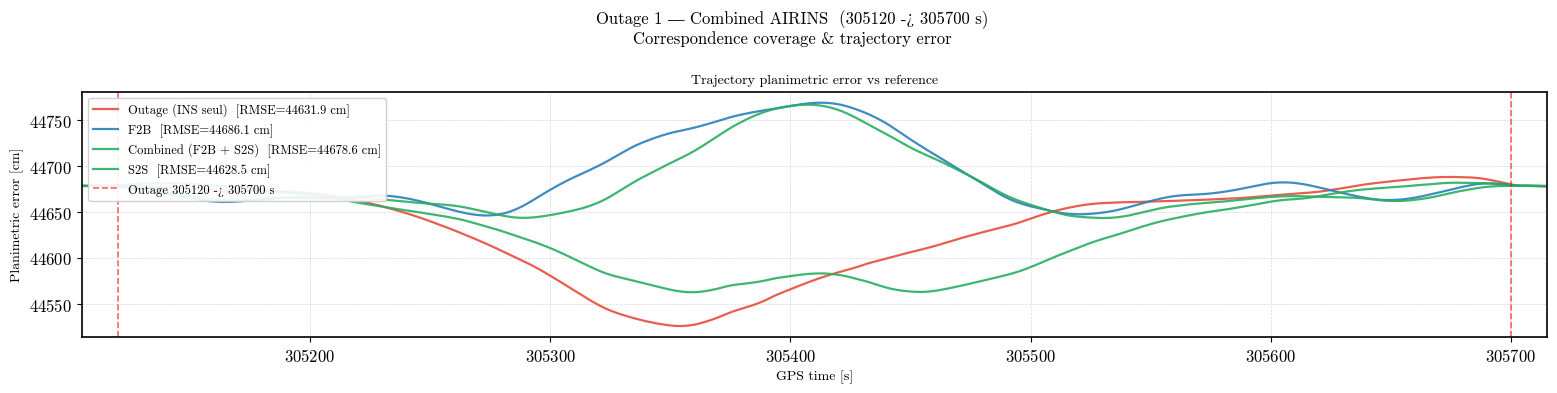

  Sauvegarde : limatch_combined_outputs/combined_plot_Outage_1_—_Combined_AIRINS.png


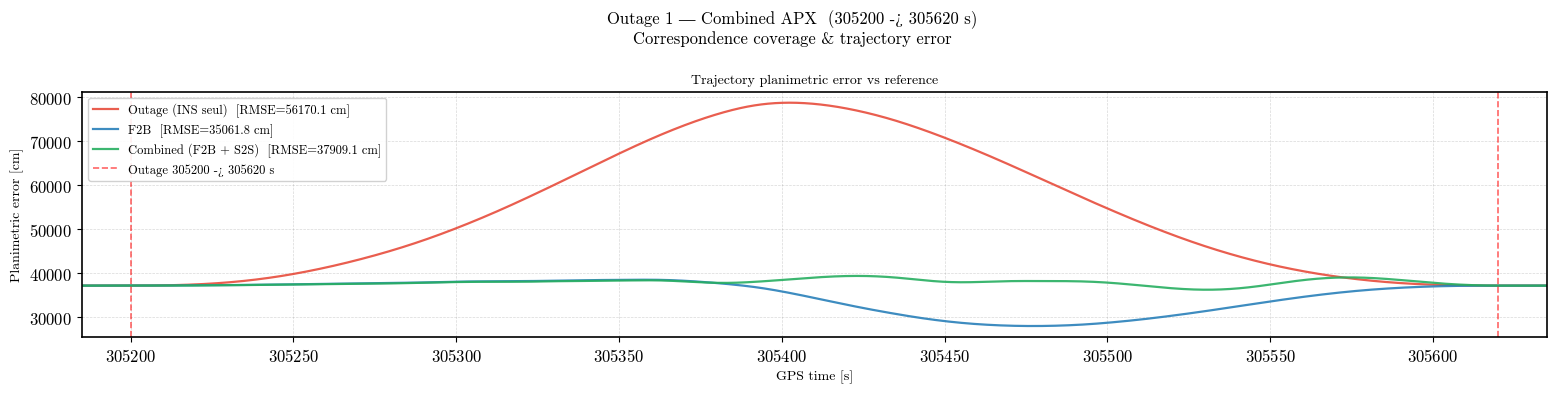

  Sauvegarde : limatch_combined_outputs/combined_plot_Outage_1_—_Combined_APX.png


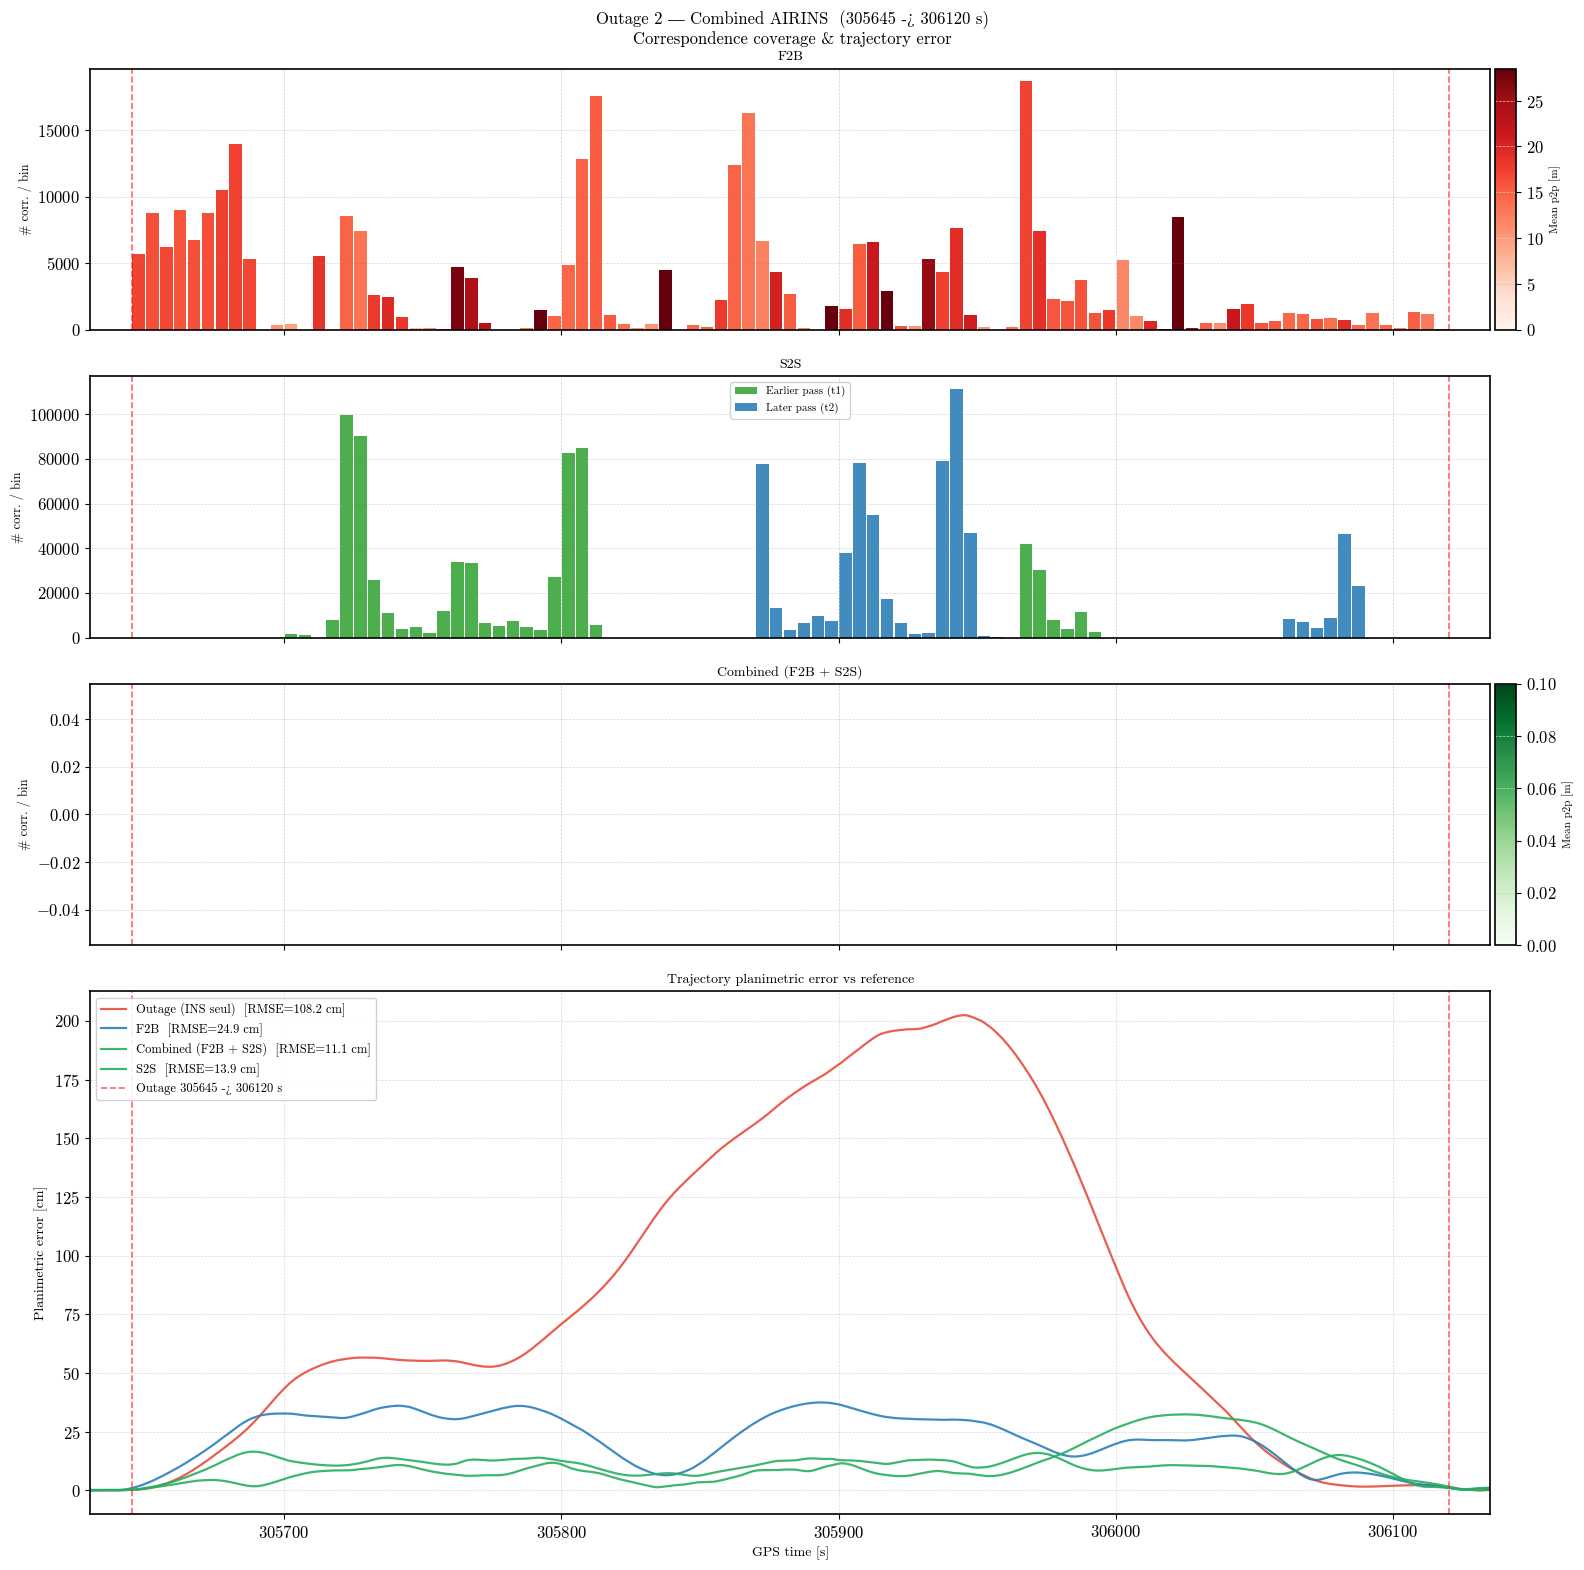

  Sauvegarde : limatch_combined_outputs/combined_plot_Outage_2_—_Combined_AIRINS.png


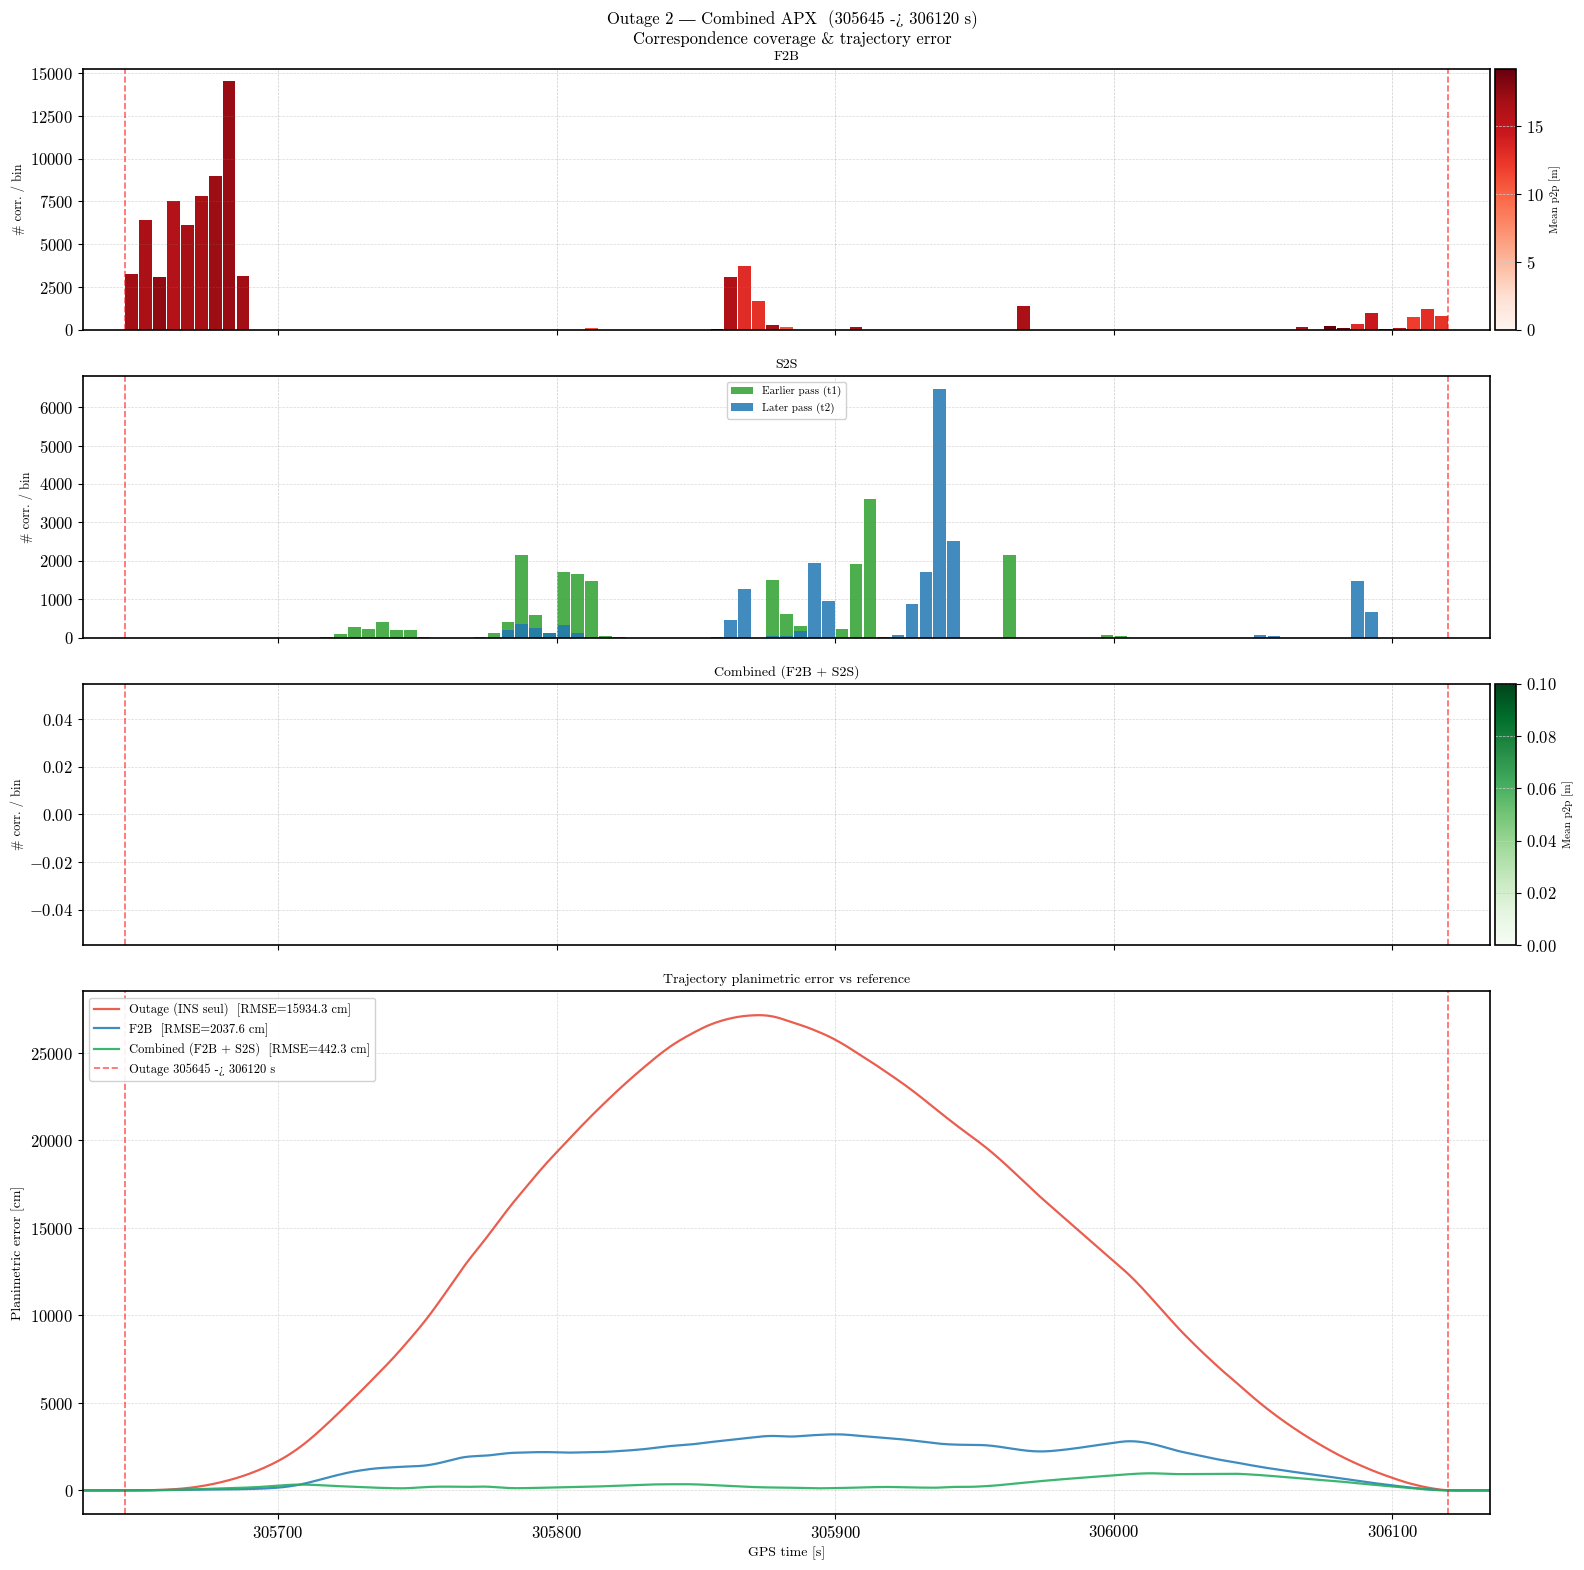

  Sauvegarde : limatch_combined_outputs/combined_plot_Outage_2_—_Combined_APX.png


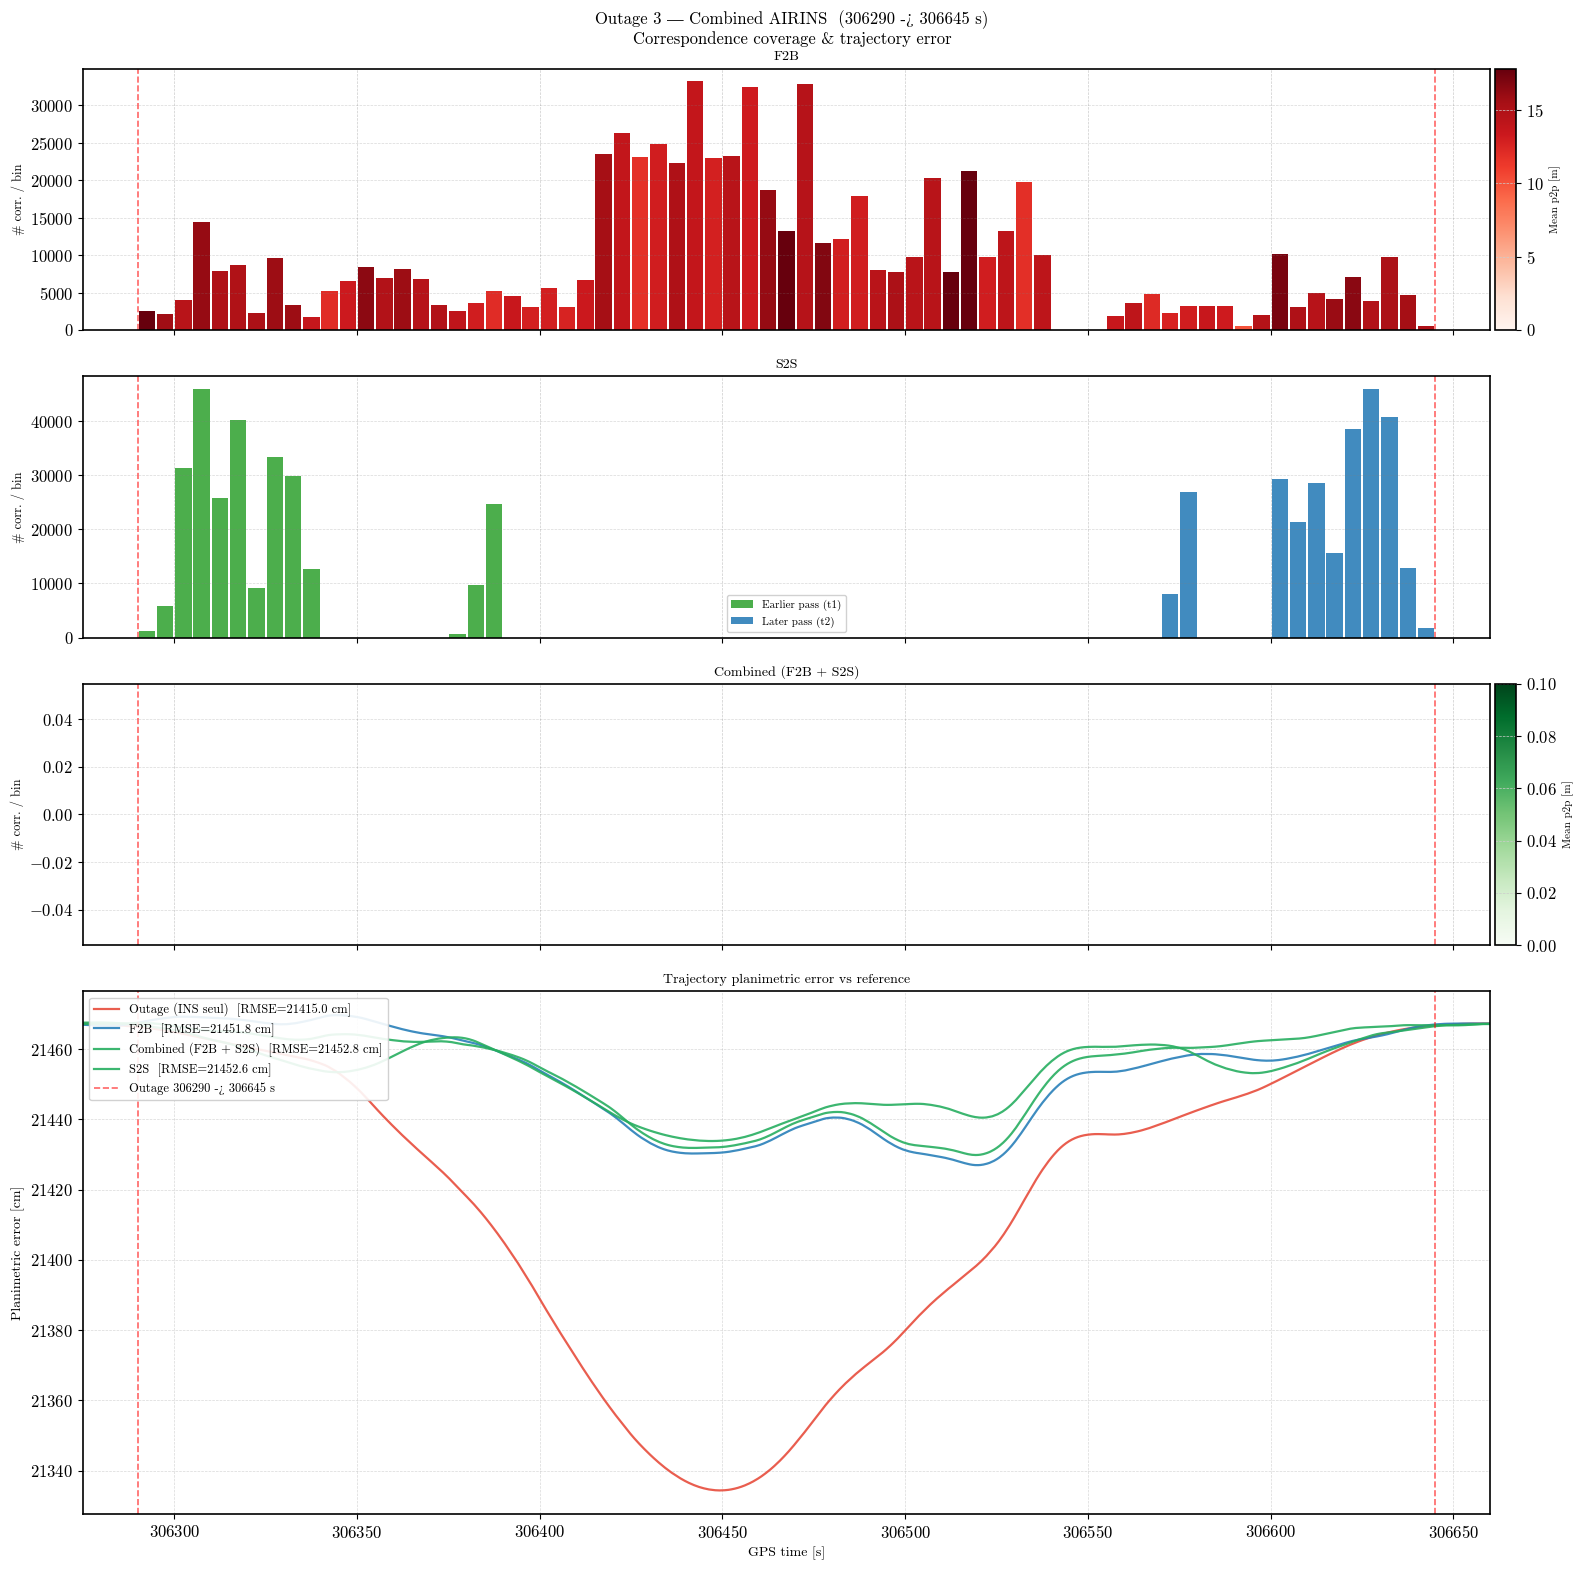

  Sauvegarde : limatch_combined_outputs/combined_plot_Outage_3_—_Combined_AIRINS.png


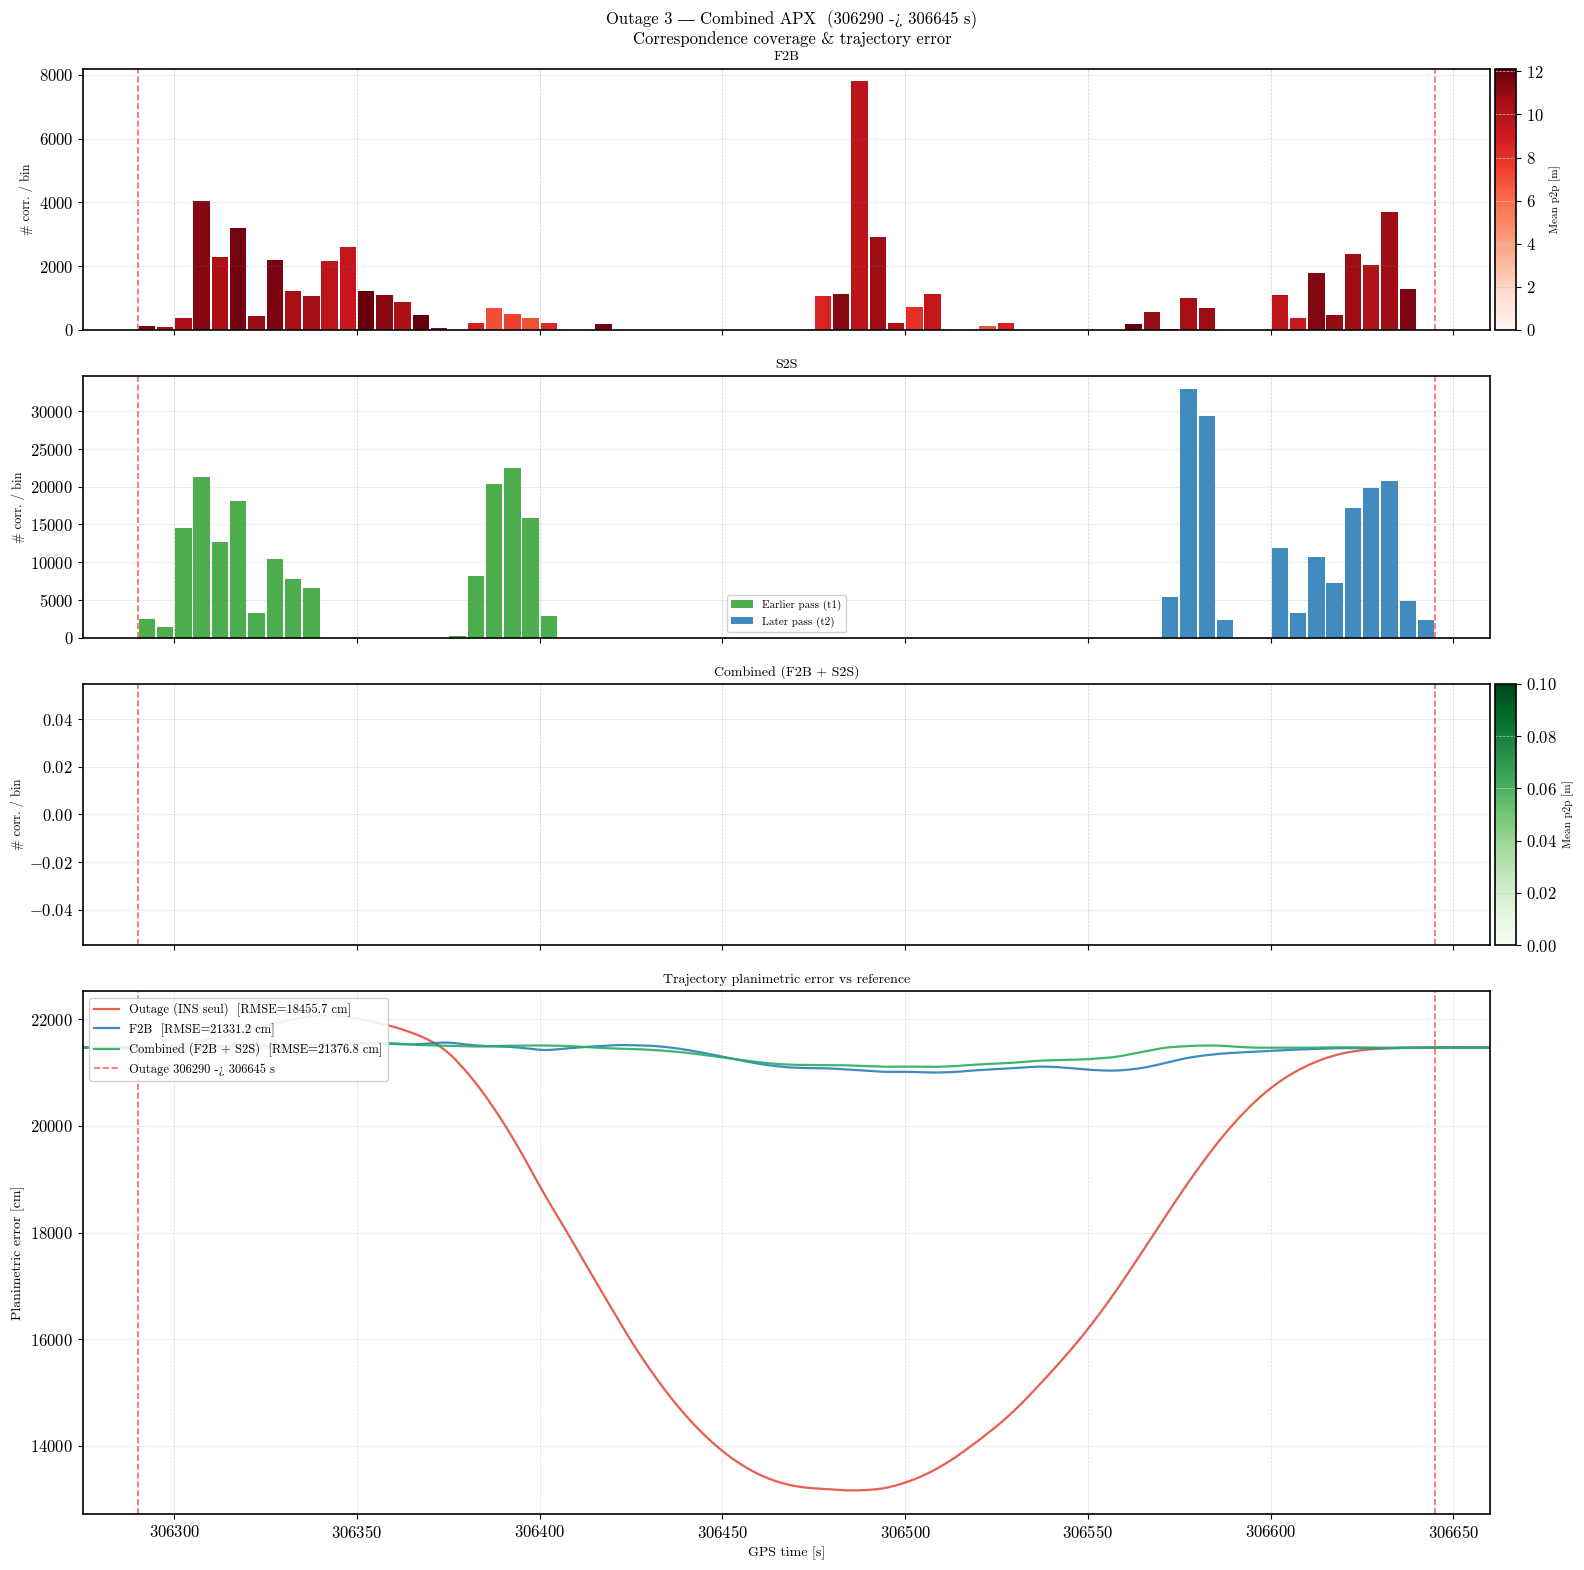

  Sauvegarde : limatch_combined_outputs/combined_plot_Outage_3_—_Combined_APX.png


In [ ]:
# ============================================================
# CELL 7 — Plot combine par scenario
# ============================================================

for sc_label, res in RESULTS.items():
    sc      = res['sc']
    t_start = res['t_start']
    t_end   = res['t_end']
    t_grid  = res['t_grid']
    errors  = res['errors']
    sources = res['sources']
    bw      = BIN_WIDTH_S

    # On affiche F2B, S2S, Combined — 3 panneaux + erreur traj
    n_src  = len(sources)
    n_rows = n_src + 1
    hr     = [1]*n_src + [2]

    fig, axes = plt.subplots(
        n_rows, 1, figsize=(16, 4*n_rows),
        sharex=True, gridspec_kw={'height_ratios': hr}
    )
    if n_rows == 1:
        axes = [axes]

    fig.suptitle(
        f'{sc_label}  ({t_start:.0f} -> {t_end:.0f} s)\n'
        'Correspondence coverage & trajectory error',
        fontsize=12
    )

    for ax_i, (src_label, df_src) in enumerate(sources.items()):
        ax = axes[ax_i]

        # Déterminer le kind : F2B = consec, S2S = crossing, Combined = les deux
        if src_label == 'F2B':
            kind = 'f2b'
        elif src_label == 'S2S':
            kind = 'crossing'
        else:
            kind = 'combined'

        if kind == 'f2b':
            # Barplot coloré par p2p moyen
            stats  = bin_temporal(df_src, t_start, t_end, bw)
            t_bins = stats['bin'].values
            counts = stats['count'].values
            mean_p = stats['mean_p2p'].values
            vmax   = np.nanpercentile(mean_p[counts>0], 95) if np.any(counts>0) else 0.1
            norm   = mcolors.Normalize(vmin=0, vmax=vmax)
            cmap   = plt.cm.Reds
            for t, cnt, p2p in zip(t_bins, counts, mean_p):
                color = 'lightgrey' if cnt == 0 else cmap(norm(p2p))
                ax.bar(t, cnt, width=bw*0.9, color=color, edgecolor='none', align='center')
            div = make_axes_locatable(ax)
            cax = div.append_axes('right', size='1.5%', pad=0.05)
            sm  = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            fig.colorbar(sm, cax=cax).set_label('Mean p2p [m]', fontsize=8)

        elif kind == 'crossing':
            # Deux séries temporelles : earlier pass (t1) et later pass (t2)
            df_cr = df_src.copy()
            swap  = df_cr['t1'] > df_cr['t2']
            df_cr.loc[swap, ['t1','t2']] = df_cr.loc[swap, ['t2','t1']].values
            bins_e = np.arange(t_start, t_end+bw, bw)
            lbl_e  = bins_e[:-1] + bw/2

            def bin_col(d, col):
                s  = d[(d[col]>=t_start) & (d[col]<=t_end)].copy()
                s['bin'] = pd.cut(s[col], bins=bins_e, labels=lbl_e).astype(float)
                st = s.groupby('bin', observed=True).agg(count=(col,'count')).reset_index()
                ab = pd.DataFrame({'bin': lbl_e})
                st = ab.merge(st, on='bin', how='left')
                st['count'] = st['count'].fillna(0).astype(int)
                return st

            sa = bin_col(df_cr, 't1')
            sb = bin_col(df_cr, 't2')
            ax.bar(sa['bin'], sa['count'], width=bw*0.9,
                   color='#2CA02C', alpha=0.85, edgecolor='none',
                   align='center', label='Earlier pass (t1)')
            ax.bar(sb['bin'], sb['count'], width=bw*0.9,
                   color='#1F77B4', alpha=0.85, edgecolor='none',
                   align='center', label='Later pass (t2)')
            ax.legend(fontsize=8)
            div = make_axes_locatable(ax)
            cax = div.append_axes('right', size='1.5%', pad=0.05)
            cax.set_visible(False)

        else:  # combined — barplot total coloré par p2p
            stats  = bin_temporal(df_src, t_start, t_end, bw)
            t_bins = stats['bin'].values
            counts = stats['count'].values
            mean_p = stats['mean_p2p'].values
            vmax   = np.nanpercentile(mean_p[counts>0], 95) if np.any(counts>0) else 0.1
            norm   = mcolors.Normalize(vmin=0, vmax=vmax)
            cmap   = plt.cm.Greens
            for t, cnt, p2p in zip(t_bins, counts, mean_p):
                color = 'lightgrey' if cnt == 0 else cmap(norm(p2p))
                ax.bar(t, cnt, width=bw*0.9, color=color, edgecolor='none', align='center')
            div = make_axes_locatable(ax)
            cax = div.append_axes('right', size='1.5%', pad=0.05)
            sm  = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            fig.colorbar(sm, cax=cax).set_label('Mean p2p [m]', fontsize=8)

        ax.set_ylabel('# corr. / bin', fontsize=9)
        ax.set_title(src_label, fontsize=10)
        ax.grid(axis='y', color='grey', ls='--', alpha=0.3)

    # Erreur planimetrique
    ax_err = axes[-1]
    mask   = (t_grid >= t_start) & (t_grid <= t_end)
    for lbl, err_dict in errors.items():
        rmse = np.sqrt(np.mean(err_dict['planim'][mask]**2)) * 100
        ax_err.plot(
            t_grid, err_dict['planim']*100,
            color=err_dict['color'], ls=err_dict['ls'],
            lw=1.6, alpha=0.9,
            label=f"{lbl}  [RMSE={rmse:.1f} cm]"
        )
    ax_err.set_ylabel('Planimetric error [cm]', fontsize=10)
    ax_err.set_xlabel('GPS time [s]', fontsize=10)
    ax_err.set_title('Trajectory planimetric error vs reference', fontsize=10)
    ax_err.grid(color='grey', ls='--', alpha=0.3)
    div = make_axes_locatable(ax_err)
    cax = div.append_axes('right', size='1.5%', pad=0.05)
    cax.set_visible(False)

    for a in axes:
        a.axvline(t_start, color='red', lw=1.2, ls='--', alpha=0.6)
        a.axvline(t_end,   color='red', lw=1.2, ls='--', alpha=0.6)
        a.set_xlim(t_start-15, t_end+15)

    handles, lbls = ax_err.get_legend_handles_labels()
    handles.append(Line2D([0],[0], color='red', lw=1.2, ls='--', alpha=0.6))
    lbls.append(f'Outage {t_start:.0f} -> {t_end:.0f} s')
    ax_err.legend(handles=handles, labels=lbls, fontsize=9, loc='upper left')

    plt.tight_layout()
    slug = re.sub(r'[ /]+', '_', sc_label)
    out  = OUTPUT_DIR / f'combined_plot_{slug}.png'
    plt.savefig(out, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'  Sauvegarde : {out}')

## Tableau recapitulatif trajectoires

In [11]:
# ============================================================
# CELL 8 — RMSE / Q50 / Q95 / Max
# ============================================================

for sc_label, res in RESULTS.items():
    mask = (res['t_grid'] >= res['t_start']) & (res['t_grid'] <= res['t_end'])
    rows = []
    for lbl, err_dict in res['errors'].items():
        e = err_dict['planim'][mask]
        rows.append({
            'Trajectory': lbl,
            'RMSE [m]'  : float(np.sqrt(np.mean(e**2))),
            'Q50 [m]'   : float(np.median(e)),
            'Q95 [m]'   : float(np.percentile(e, 95)),
            'Max [m]'   : float(np.max(e)),
        })
    df_r = pd.DataFrame(rows).set_index('Trajectory')
    print(f"\n=== {sc_label} — trajectory error ===")
    display(df_r.round(4))


=== Outage 1 — Combined AIRINS — trajectory error ===


,RMSE [m],Q50 [m],Q95 [m],Max [m]
Trajectory,,,,
Outage (INS seul),446.3186,446.5632,446.8574,446.8785
F2B,446.8615,446.7051,447.6333,447.6852
Combined (F2B + S2S),446.7862,446.6576,447.6024,447.6639
S2S,446.2848,446.4012,446.8094,446.8162



=== Outage 1 — Combined APX — trajectory error ===


,RMSE [m],Q50 [m],Q95 [m],Max [m]
Trajectory,,,,
Outage (INS seul),561.7010,508.8414,781.7844,787.1749
F2B,350.6182,369.8536,384.2966,385.0313
Combined (F2B + S2S),379.0912,379.8763,390.9540,393.6379


## Success rate


SCENARIO : Outage 1 — Combined AIRINS
  [S2S]  274/532 (51.5%)  | 163,252 corr.
  [S2S]  50/391 (12.8%)  | 83,667 corr.
  [Combined (F2B + S2S)]  324/923 (35.1%)  | 246,919 corr.


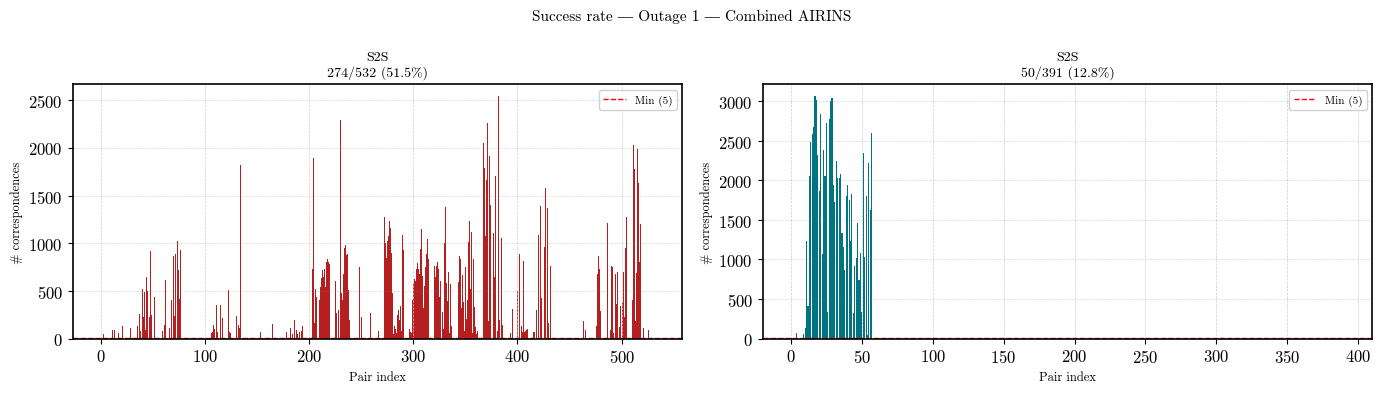

  Sauvegarde : limatch_combined_outputs/success_rate_Outage_1_—_Combined_AIRINS.png

SCENARIO : Outage 1 — Combined APX


KeyError: 'success'

In [12]:
# ============================================================
# CELL 9 — Success rate par source LiDAR
# ============================================================

def compute_success_rate(root: Path) -> pd.DataFrame:
    rows = []
    for merged_dir in sorted(root.iterdir()):
        if not merged_dir.is_dir() or not merged_dir.name.startswith('merged_'):
            continue
        for pair_dir in sorted(merged_dir.iterdir()):
            if not pair_dir.is_dir() or '__' not in pair_dir.name:
                continue
            p2p_files = list(pair_dir.rglob('LiDAR_p2p_chunk_*.txt'))
            n_corres  = 0
            for fp in p2p_files:
                try:
                    n_corres += len(read_lidar_p2p_file(fp))
                except Exception:
                    pass
            rows.append({
                'merged_parent': merged_dir.name,
                'pair_dir'     : pair_dir.name,
                'n_corres'     : n_corres,
                'success'      : n_corres >= MIN_CORRES,
            })
    return pd.DataFrame(rows)


for sc_label, res in RESULTS.items():
    sc = res['sc']
    print(f"\n{'='*60}")
    print(f"SCENARIO : {sc_label}")

    sr_list = []
    for src in sc['lidar_sources']:
        sr        = compute_success_rate(src['root'])
        kind_lbl  = 'F2B' if src['kind'] == 'f2b' else 'S2S'
        sr['source_label'] = kind_lbl
        sr_list.append((src, sr, kind_lbl))
        n_tot = len(sr)
        n_ok  = int(sr['success'].sum())
        rate  = 100*n_ok/n_tot if n_tot > 0 else 0
        print(f"  [{kind_lbl}]  {n_ok}/{n_tot} ({rate:.1f}%)  | {sr['n_corres'].sum():,} corr.")

    # Combined = F2B + S2S fusionnés
    if len(sr_list) == 2:
        sr_comb = pd.concat([sr_list[0][1], sr_list[1][1]], ignore_index=True)
        n_tot = len(sr_comb)
        n_ok  = int(sr_comb['success'].sum())
        rate  = 100*n_ok/n_tot if n_tot > 0 else 0
        print(f"  [Combined (F2B + S2S)]  {n_ok}/{n_tot} ({rate:.1f}%)  | {sr_comb['n_corres'].sum():,} corr.")

    n_src = len(sr_list)
    fig, axes = plt.subplots(1, n_src, figsize=(7*n_src, 4))
    if n_src == 1:
        axes = [axes]

    for ax, (src, sr, kind_lbl) in zip(axes, sr_list):
        colors = [src['color'] if s else 'lightgrey' for s in sr['success']]
        ax.bar(range(len(sr)), sr['n_corres'], color=colors, edgecolor='none')
        ax.axhline(MIN_CORRES, color='red', lw=1, ls='--',
                   label=f'Min ({MIN_CORRES})')
        n_ok = sr['success'].sum()
        ax.set_title(
            f"{kind_lbl}\n{n_ok}/{len(sr)} ({100*n_ok/len(sr):.1f}%)",
            fontsize=10
        )
        ax.set_xlabel('Pair index', fontsize=9)
        ax.set_ylabel('# correspondences', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(axis='y', color='grey', ls='--', alpha=0.3)

    plt.suptitle(f'Success rate — {sc_label}', fontsize=11)
    plt.tight_layout()
    slug = re.sub(r'[ /]+', '_', sc_label)
    out  = OUTPUT_DIR / f'success_rate_{slug}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Sauvegarde : {out}')

## Open3D — visualisation paire de chunks

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

[O3d] Outage 2 — Combined AIRINS
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/F2B_z3/out/F2B_out3_apx.out
  [Open3D] -> [Q] pour fermer
limatch_combined_outputs/legend_o3d_Outage_2_—_Combined_AIRINS.png


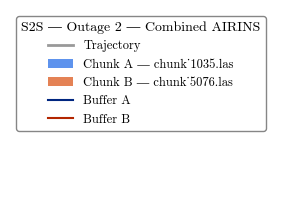

  Legende : limatch_combined_outputs/legend_o3d_Outage_2_—_Combined_AIRINS.png

[O3d] Outage 3 — Combined AIRINS


KeyError: 'bbox_a_csv'

In [ ]:
# ============================================================
# CELL 10 — O3d pour chaque scenario qui a une config o3d
# ============================================================

import open3d as o3d
from pyproj import Transformer

def make_pcd_shaded(xyz_c, base_color, subsample=2, alpha=0.7):
    xyz_s = xyz_c[::subsample]
    pcd   = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz_s)
    z      = xyz_s[:,2]
    z_norm = (z-z.min())/(z.max()-z.min()+1e-9)
    bc     = np.array(base_color)
    colors = np.outer(z_norm,bc) + np.outer(1-z_norm,bc*0.4)
    colors = colors*alpha + np.ones_like(colors)*(1-alpha)
    pcd.colors = o3d.utility.Vector3dVector(np.clip(colors,0,1))
    return pcd

def make_lineset(xyz_c, color):
    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(xyz_c)
    ls.lines  = o3d.utility.Vector2iVector(
        [[i,i+1] for i in range(len(xyz_c)-1)])
    ls.paint_uniform_color(color)
    return ls

def traj_buffer_lineset(xyz_seg, margin, color, hatch_spacing=1.0):
    if len(xyz_seg) < 2:
        return None
    left, right = [], []
    for i in range(len(xyz_seg)):
        i0 = max(0,i-1) if i==len(xyz_seg)-1 else i
        dx = xyz_seg[i0+1,0]-xyz_seg[i0,0]
        dy = xyz_seg[i0+1,1]-xyz_seg[i0,1]
        ln = np.sqrt(dx**2+dy**2)+1e-9
        nx, ny = -dy/ln, dx/ln
        left.append( xyz_seg[i]+np.array([ nx*margin, ny*margin,0]))
        right.append(xyz_seg[i]+np.array([-nx*margin,-ny*margin,0]))
    left, right = np.array(left), np.array(right)
    n     = len(left)
    pts   = list(left)+list(right)
    lines = ([[i,i+1] for i in range(n-1)] +
             [[n+i,n+i+1] for i in range(n-1)] +
             [[0,n],[n-1,2*n-1]])
    dist, next_h = 0.0, 0.0
    for i in range(n-1):
        sl = np.linalg.norm(left[i+1]-left[i])
        while next_h <= dist+sl:
            t_ = np.clip((next_h-dist)/(sl+1e-9),0,1)
            pl = left[i] +t_*(left[i+1]-left[i])
            pr = right[i]+t_*(right[i+1]-right[i])
            b  = len(pts)
            pts += [pl,pr]
            lines.append([b,b+1])
            next_h += hatch_spacing
        dist += sl
    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(np.array(pts))
    ls.lines  = o3d.utility.Vector2iVector(lines)
    ls.paint_uniform_color(color)
    return ls


for sc_label, res in RESULTS.items():
    cfg = res['sc'].get('o3d')
    if cfg is None:
        print(f'[O3d] {sc_label} — desactive')
        continue

    print(f'\n[O3d] {sc_label}')

    bbox_a = pd.read_csv(cfg['bbox_a_csv'])
    bbox_b = pd.read_csv(cfg['bbox_b_csv'])
    row_a  = bbox_a[bbox_a['chunk_file']==cfg['chunk_a_name']].iloc[0]
    row_b  = bbox_b[bbox_b['chunk_file']==cfg['chunk_b_name']].iloc[0]
    t_a0, t_a1 = row_a['t_start'], row_a['t_end']
    t_b0, t_b1 = row_b['t_start'], row_b['t_end']

    trj_o3d   = Trajectory.fromSBET(cfg['sbet_path'], {'type':'SBET'})
    ecef2lv95 = Transformer.from_crs('EPSG:4978','EPSG:2056',always_xy=False)
    xt,yt,zt  = ecef2lv95.transform(
        trj_o3d.ecef[:,0], trj_o3d.ecef[:,1], trj_o3d.ecef[:,2])
    xyz_trj = np.vstack((xt,yt,zt)).T

    mask_a    = (trj_o3d.time>=t_a0)&(trj_o3d.time<=t_a1)
    mask_b    = (trj_o3d.time>=t_b0)&(trj_o3d.time<=t_b1)
    mask_full = ((trj_o3d.time>=min(t_a0,t_b0)-30)&
                 (trj_o3d.time<=max(t_a1,t_b1)+30))

    las_a  = laspy.read(cfg['chunk_a'])
    las_b  = laspy.read(cfg['chunk_b'])
    xyz_a  = np.vstack((las_a.x,las_a.y,las_a.z)).T
    xyz_b  = np.vstack((las_b.x,las_b.y,las_b.z)).T
    center = np.vstack([xyz_a,xyz_b,xyz_trj[mask_full]]).mean(axis=0)
    sh     = lambda arr: arr - center

    pcd_a   = make_pcd_shaded(sh(xyz_a),          [0.1,0.4,0.9],   subsample=2, alpha=0.7)
    pcd_b   = make_pcd_shaded(sh(xyz_b),          [0.85,0.3,0.05], subsample=2, alpha=0.7)
    ls_full = make_lineset(sh(xyz_trj[mask_full]), [0.6,0.6,0.6])
    ls_a    = make_lineset(sh(xyz_trj[mask_a]),    [1.0,1.0,1.0])
    ls_b    = make_lineset(sh(xyz_trj[mask_b]),    [1.0,1.0,1.0])
    buf_a   = traj_buffer_lineset(sh(xyz_trj[mask_a]),cfg['margin_m'],[0.0,0.15,0.5],1.5)
    buf_b   = traj_buffer_lineset(sh(xyz_trj[mask_b]),cfg['margin_m'],[0.7,0.15,0.0],1.5)

    geoms = [pcd_a, pcd_b, ls_full, ls_a, ls_b]
    if buf_a: geoms.append(buf_a)
    if buf_b: geoms.append(buf_b)

    print('  [Open3D] -> [Q] pour fermer')
    o3d.visualization.draw_geometries(
        geoms,
        window_name=f"{sc_label} | bleu={cfg['chunk_a_name']} orange={cfg['chunk_b_name']}",
        width=1400, height=900,
    )

    fig_leg, ax_leg = plt.subplots(figsize=(3.2,2.2))
    ax_leg.axis('off')
    leg_elems = [
        Line2D([0],[0],color=[0.6,0.6,0.6],lw=2,label='Trajectory'),
        mpatches.Patch(facecolor=[0.1,0.4,0.9],  alpha=0.7,label=f"Chunk A — {cfg['chunk_a_name']}"),
        mpatches.Patch(facecolor=[0.85,0.3,0.05],alpha=0.7,label=f"Chunk B — {cfg['chunk_b_name']}"),
        Line2D([0],[0],color=[0.0,0.15,0.5],lw=1.5,label='Buffer A'),
        Line2D([0],[0],color=[0.7,0.15,0.0],lw=1.5,label='Buffer B'),
    ]
    ax_leg.legend(handles=leg_elems,loc='upper left',
                  fontsize=9,frameon=True,framealpha=0.95,
                  edgecolor='gray',
                  title=f'S2S — {sc_label}',title_fontsize=10)
    plt.tight_layout()
    slug = re.sub(r'[ /]+','_', sc_label)
    leg_path = OUTPUT_DIR / f'legend_o3d_{slug}.png'
    plt.savefig(leg_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Legende : {leg_path}')

## 2eme approche

Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/OUTAGE/out/outage_1.out
Outage duration : 579.9s
Total distance  : 7858.5m
Number of chunks: 524
Loaded 230282 correspondences
Consecutive pairs: 192853
Chunk pairs with 0 correspondences: 118/523


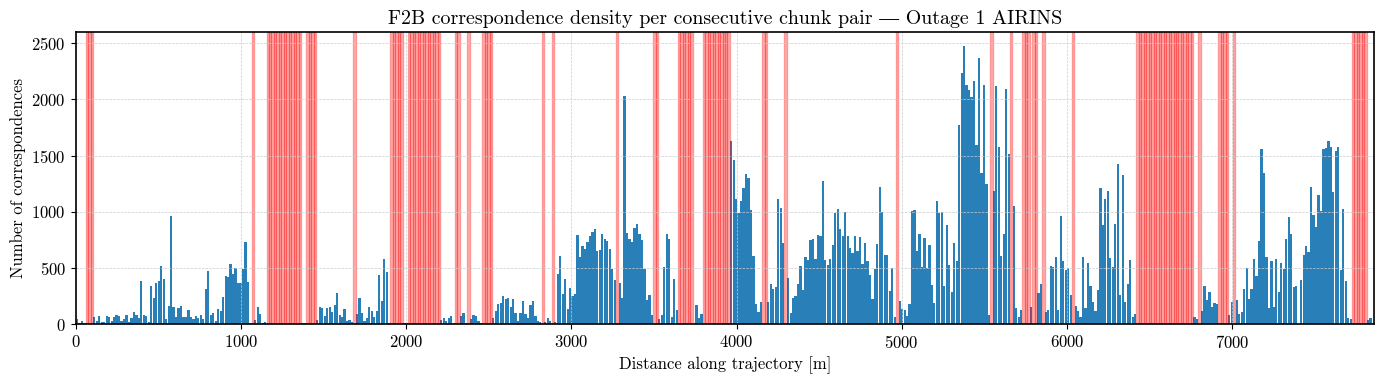

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from lib.loaders import loadSBET

# ============================================================
# INPUTS
# ============================================================

SBET_PATH = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/OUTAGE/out/outage_1.out"
LIDAR_P2P_PATH = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/F2B/in/LiDAR_p2p.txt"

T_START = 305120.0
T_END   = 305700.0
CHUNK_SIZE_M = 15.0

cfg = {"type": "SBET", "timeRef": "GPS"}

P2P_COLS = ["time_a", "time_b",
            "x_a", "y_a", "z_a",
            "x_b", "y_b", "z_b"]



# ============================================================
# CHARGEMENT TRAJ + SEGMENTATION EN CHUNKS
# ============================================================

time_ref, _, ecef_ref, _ = loadSBET(SBET_PATH, cfg)

# Crop sur la fenetre d'outage
mask = (time_ref >= T_START) & (time_ref <= T_END)
t = time_ref[mask]
xyz = ecef_ref[mask]

# Distance cumulée
dists = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(xyz, axis=0), axis=1))])

# Attribution chunk par timestamp
chunk_ids = (dists // CHUNK_SIZE_M).astype(int)
n_chunks = chunk_ids[-1] + 1

# Interpolateur timestamp -> chunk_id
from scipy.interpolate import interp1d
t_to_chunk = interp1d(t, chunk_ids, kind='nearest',
                       bounds_error=False, fill_value=-1)

print(f"Outage duration : {t[-1]-t[0]:.1f}s")
print(f"Total distance  : {dists[-1]:.1f}m")
print(f"Number of chunks: {n_chunks}")

# ============================================================
# CHARGEMENT CORRESPONDANCES
# ============================================================

df = pd.read_csv(LIDAR_P2P_PATH, header=None, names=P2P_COLS,
                 sep=r",\s*", engine="python")
df = df.apply(pd.to_numeric, errors="coerce").dropna()
print(f"Loaded {len(df)} correspondences")

# Attribution chunk pour chaque correspondance
df["chunk_a"] = t_to_chunk(df["time_a"].values).astype(int)
df["chunk_b"] = t_to_chunk(df["time_b"].values).astype(int)

# Garder uniquement les paires consécutives (|chunk_a - chunk_b| == 1)
df["chunk_diff"] = (df["chunk_b"] - df["chunk_a"]).abs()
df_consec = df[df["chunk_diff"] == 1].copy()
df_consec["chunk_min"] = df_consec[["chunk_a","chunk_b"]].min(axis=1)

df["d_xyz"] = np.sqrt(
    (df["x_a"] - df["x_b"])**2 +
    (df["y_a"] - df["y_b"])**2 +
    (df["z_a"] - df["z_b"])**2
)

print(f"Consecutive pairs: {len(df_consec)}")

# ============================================================
# COMPTAGE PAR PAIRE DE CHUNKS
# ============================================================

corr_per_pair = df_consec.groupby("chunk_min").size().reset_index(name="n_corr")

# Distance de chaque chunk (milieu)
chunk_centers = np.arange(n_chunks) * CHUNK_SIZE_M + CHUNK_SIZE_M / 2

# Merge
pair_dist = pd.DataFrame({
    "chunk_min": np.arange(n_chunks - 1),
    "dist_m": chunk_centers[:n_chunks-1]
})
pair_dist = pair_dist.merge(corr_per_pair, on="chunk_min", how="left")
pair_dist["n_corr"] = pair_dist["n_corr"].fillna(0).astype(int)

n_empty = (pair_dist["n_corr"] == 0).sum()
print(f"Chunk pairs with 0 correspondences: {n_empty}/{len(pair_dist)}")

# ============================================================
# PLOT
# ============================================================

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(pair_dist["dist_m"], pair_dist["n_corr"],
       width=CHUNK_SIZE_M * 0.9, color="#2980B9", edgecolor="none")
ax.axhline(0, color="black", lw=0.5)

# Marquer les paires vides
empty_pairs = pair_dist[pair_dist["n_corr"] == 0]
for _, row in empty_pairs.iterrows():
    ax.axvspan(row["dist_m"] - CHUNK_SIZE_M/2,
               row["dist_m"] + CHUNK_SIZE_M/2,
               color="red", alpha=0.3)

# Crop de 0 à la fin de la trajectoire
ax.set_xlim(0, dists[-1])
ax.set_xlabel("Distance along trajectory [m]")
ax.set_ylabel("Number of correspondences")
ax.set_title("F2B correspondence density per consecutive chunk pair — Outage 1 AIRINS")

plt.tight_layout()
plt.show()

Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/F2B/in/reference.out
  Outage 1 — AIRINS: 230282 corr | 172271 consec | 108/524 empty pairs | SR=79.4% | d=7861m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/F2B/in/reference.out
  Outage 2 — AIRINS: 156443 corr | 94077 consec | 31/237 empty pairs | SR=86.9% | d=3564m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/F2B/in/reference.out
  Outage 3 — AIRINS: 342502 corr | 232152 consec | 2/172 empty pairs | SR=98.8% | d=2585m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/in/reference.out
  Outage 1 — APX15: 56982 corr | 35089 consec | 75/363 empty pairs | SR=79.3% | d=5451m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/reference.out
  Outage 2 — APX15: 39899 corr | 26611 consec | 155/237 empty pairs | SR=34.6% | d=3564m
Loading file /m

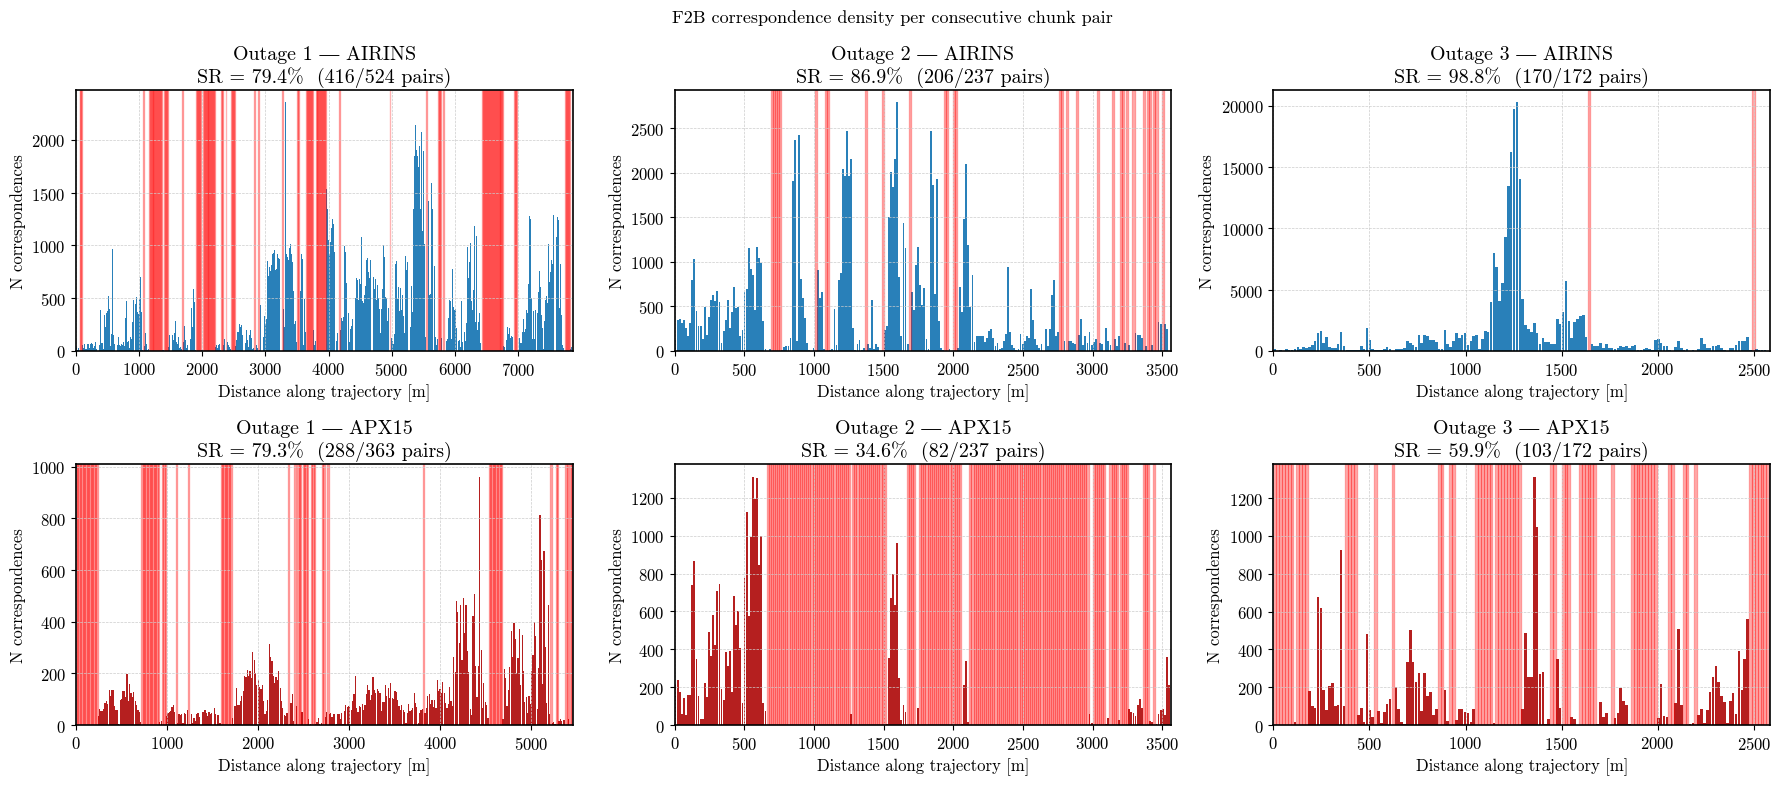

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from lib.loaders import loadSBET

# ============================================================
# INPUTS
# ============================================================

cfg = {"type": "SBET", "timeRef": "GPS"}
CHUNK_SIZE_M = 15.0

SBET_REF_AIRINS = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/out/ODyN_CALIB.out"
SBET_REF_APX    = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/base/out/CALIB_APX.out"

SCENARIOS = [
    {
        "label"   : "Outage 1 — AIRINS",
        "sbet"    : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/F2B/in/reference.out",
        "p2p"     : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/F2B/in/LiDAR_p2p.txt",
        "t_start" : 305120.0,
        "t_end"   : 305700.0,
        "cfg"     : {"type": "SBET", "timeRef": "GPS"},
    },
    {
        "label"   : "Outage 2 — AIRINS",
        "sbet"    : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/F2B/in/reference.out",
        "p2p"     : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/F2B/in/LiDAR_p2p.txt",
        "t_start" : 305645.0,
        "t_end"   : 306120.0,
        "cfg"     : {"type": "SBET", "timeRef": "GPS"},
    },
    {
        "label"   : "Outage 3 — AIRINS",
        "sbet"    : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/F2B/in/reference.out",
        "p2p"     : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/F2B/in/LiDAR_p2p.txt",
        "t_start" : 306290.0,
        "t_end"   : 306645.0,
        "cfg"     : {"type": "SBET", "timeRef": "GPS"},
    },
    {
        "label"   : "Outage 1 — APX15",
        "sbet"    : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/in/reference.out",
        "p2p"     : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/in/LiDAR_p2p.txt",
        "t_start" : 305200.0,
        "t_end"   : 305620.0,
        "cfg"     : {"type": "SBET", "timeRef": "GPS"},
    },
    {
        "label"   : "Outage 2 — APX15",
        "sbet"    : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/reference.out",
        "p2p"     : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/v2/LiDAR_p2p.txt",
        "t_start" : 305645.0,
        "t_end"   : 306120.0,
        "cfg"     : {"type": "SBET", "timeRef": "GPS"},
    },
    {
        "label"   : "Outage 3 — APX15",
        "sbet"    : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/F2B/in/reference.out",
        "p2p"     : "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/F2B/in/LiDAR_p2p.txt",
        "t_start" : 306290.0,
        "t_end"   : 306645.0,
        "cfg"     : {"type": "SBET", "timeRef": "GPS"},
    },
]

P2P_COLS = ["time_a", "time_b",
            "x_a", "y_a", "z_a",
            "x_b", "y_b", "z_b"]

# ============================================================
# FONCTION PRINCIPALE
# ============================================================

def process_scenario(sc):
    label    = sc["label"]
    t_start  = sc["t_start"]
    t_end    = sc["t_end"]
    cfg_sc   = sc.get("cfg", cfg)

    time_ref, _, ecef_ref, _ = loadSBET(sc["sbet"], cfg_sc)
    mask = (time_ref >= t_start) & (time_ref <= t_end)
    t   = time_ref[mask]
    xyz = ecef_ref[mask]

    dists     = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(xyz, axis=0), axis=1))])
    chunk_ids = (dists // CHUNK_SIZE_M).astype(int)
    n_chunks  = chunk_ids[-1] + 1
    t_to_chunk = interp1d(t, chunk_ids, kind='nearest',
                          bounds_error=False, fill_value=-1)

    try:
        df = pd.read_csv(sc["p2p"], header=None, names=P2P_COLS,
                         sep=r",\s*", engine="python")
        df = df.apply(pd.to_numeric, errors="coerce").dropna()
    except Exception as e:
        print(f"  ERROR loading {sc['p2p']}: {e}")
        return None

    df["chunk_a"]    = t_to_chunk(df["time_a"].values).astype(int)
    df["chunk_b"]    = t_to_chunk(df["time_b"].values).astype(int)
    df["chunk_diff"] = (df["chunk_b"] - df["chunk_a"]).abs()
    df_consec        = df[df["chunk_diff"] == 1].copy()
    df_consec["chunk_min"] = df_consec[["chunk_a","chunk_b"]].min(axis=1)

    corr_per_pair = df_consec.groupby("chunk_min").size().reset_index(name="n_corr")

    chunk_centers = np.arange(n_chunks) * CHUNK_SIZE_M + CHUNK_SIZE_M / 2
    pair_dist = pd.DataFrame({
        "chunk_min": np.arange(n_chunks - 1),
        "dist_m"   : chunk_centers[:n_chunks-1]
    })
    pair_dist = pair_dist.merge(corr_per_pair, on="chunk_min", how="left")
    pair_dist["n_corr"] = pair_dist["n_corr"].fillna(0).astype(int)

    n_empty = (pair_dist["n_corr"] == 0).sum()
    n_pairs = len(pair_dist)
    sr = (n_pairs - n_empty) / n_pairs * 100

    print(f"  {label}: {len(df)} corr | {len(df_consec)} consec | "
          f"{n_empty}/{n_pairs} empty pairs | SR={sr:.1f}% | d={dists[-1]:.0f}m")

    return pair_dist, dists[-1], label, sr, n_pairs, n_empty


# ============================================================
# PLOT 2x3
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, sc in zip(axes, SCENARIOS):
    result = process_scenario(sc)
    if result is None:
        ax.set_title(sc["label"] + " — ERROR")
        continue

    pair_dist, d_total, label, sr, n_pairs, n_empty = result  # 6 valeurs
    empty_pairs = pair_dist[pair_dist["n_corr"] == 0]

    ax.bar(pair_dist["dist_m"], pair_dist["n_corr"],
           width=CHUNK_SIZE_M * 0.9,
           color="#B51F1F" if "APX" in label else "#2980B9",
           edgecolor="none")

    for _, row in empty_pairs.iterrows():
        ax.axvspan(row["dist_m"] - CHUNK_SIZE_M/2,
                   row["dist_m"] + CHUNK_SIZE_M/2,
                   color="red", alpha=0.3)

    ax.set_xlim(0, d_total)
    ax.set_xlabel("Distance along trajectory [m]")
    ax.set_ylabel("N correspondences")
    ax.set_title(f"{label}\nSR = {sr:.1f}%  ({n_pairs - n_empty}/{n_pairs} pairs)")

plt.suptitle("F2B correspondence density per consecutive chunk pair", fontsize=13)
plt.tight_layout()
plt.show()

Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_1_305120_305700/F2B/in/reference.out
  Outage 1 — AIRINS: 230282 corr | 172271 consec | 108/524 empty pairs | SR=79.4% | d=7861m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/F2B/in/reference.out
  Outage 2 — AIRINS: 156443 corr | 94077 consec | 31/237 empty pairs | SR=86.9% | d=3564m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_3_306295_306640/F2B/in/reference.out
  Outage 3 — AIRINS: 342502 corr | 232152 consec | 2/172 empty pairs | SR=98.8% | d=2585m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/in/reference.out
  Outage 1 — APX15: 56982 corr | 35089 consec | 75/363 empty pairs | SR=79.3% | d=5451m
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/in/reference.out
  Outage 2 — APX15: 39899 corr | 26611 consec | 155/237 empty pairs | SR=34.6% | d=3564m
Loading file /m

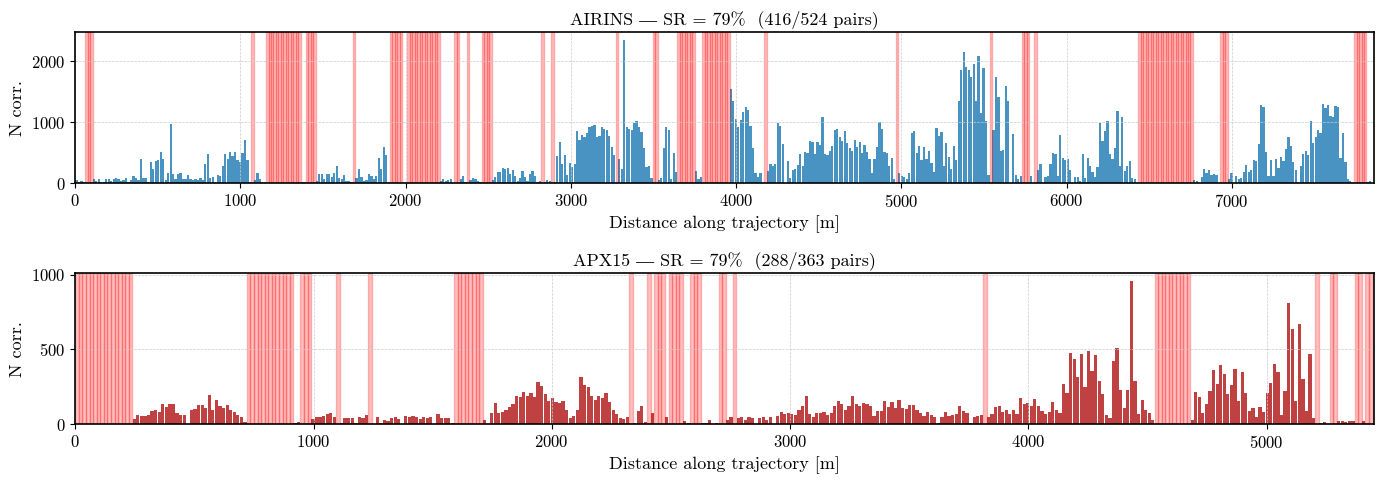

Saved: f2b_corr_density_outage1.png


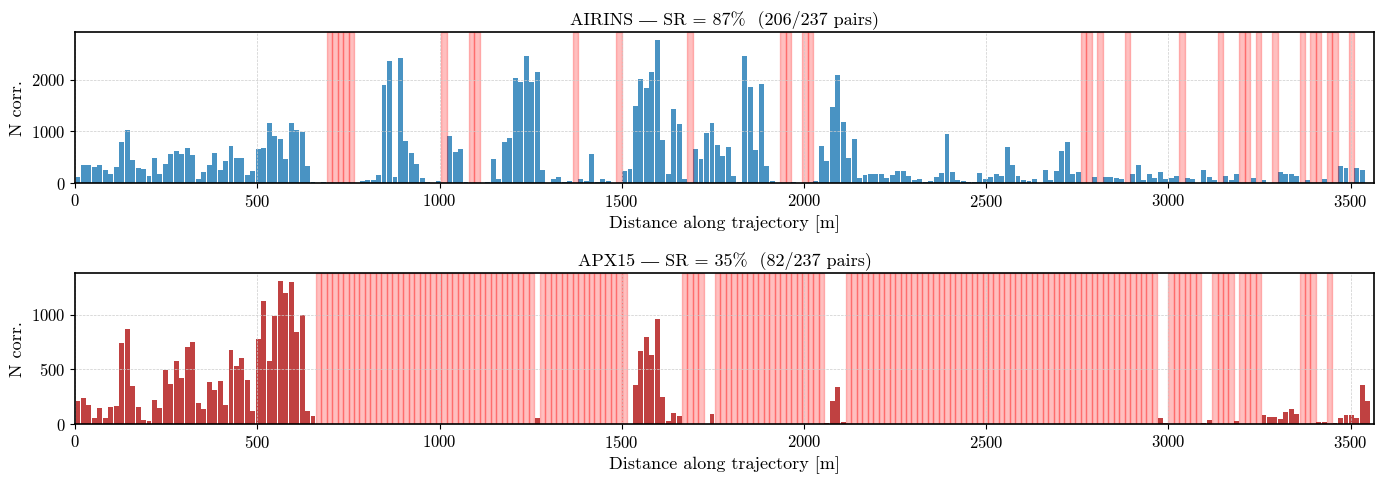

Saved: f2b_corr_density_outage2.png


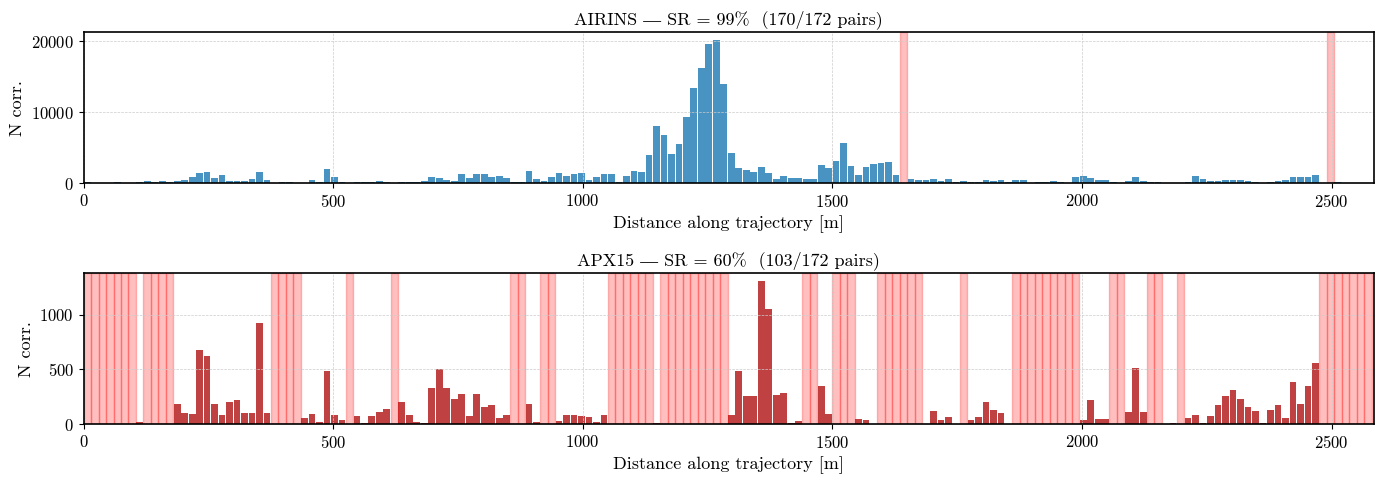

Saved: f2b_corr_density_outage3.png


In [ ]:
# ============================================================
# PLOT 1x3 — un plot par outage, AIRINS vs APX15
# ============================================================

OUTAGES = [
    {
        "title"  : "Outage 1",
        "airins" : None,  # sera rempli lors du traitement
        "apx"    : None,
    },
    {
        "title"  : "Outage 2",
        "airins" : None,
        "apx"    : None,
    },
    {
        "title"  : "Outage 3",
        "airins" : None,
        "apx"    : None,
    },
]

# Re-traiter les scénarios et stocker les résultats
results_by_label = {}
for sc in SCENARIOS:
    result = process_scenario(sc)
    if result is not None:
        pair_dist, d_total, label, sr, n_pairs, n_empty = result
        results_by_label[label] = {
            "pair_dist": pair_dist,
            "d_total"  : d_total,
            "sr"       : sr,
            "n_pairs"  : n_pairs,
            "n_empty"  : n_empty,
        }

for outage_num in [1, 2, 3]:
    label_airins = f"Outage {outage_num} — AIRINS"
    label_apx    = f"Outage {outage_num} — APX15"

    r_air = results_by_label.get(label_airins)
    r_apx = results_by_label.get(label_apx)

    fig, axes = plt.subplots(2, 1, figsize=(14, 5))

    for ax, (r, color, imu_label) in zip(axes, [
        (r_air, "#2980B9", "AIRINS"),
        (r_apx, "#B51F1F", "APX15"),
    ]):
        if r is None:
            ax.set_title(f"Outage {outage_num} — {imu_label} — No data", fontsize=13)
            continue

        pd_ = r["pair_dist"]
        empty = pd_[pd_["n_corr"] == 0]

        ax.bar(pd_["dist_m"], pd_["n_corr"],
               width=CHUNK_SIZE_M * 0.9,
               color=color, alpha=0.85,
               edgecolor="none")

        for _, row_ in empty.iterrows():
            ax.axvspan(row_["dist_m"] - CHUNK_SIZE_M/2,
                       row_["dist_m"] + CHUNK_SIZE_M/2,
                       color="red", alpha=0.25)

        ax.set_xlim(0, r["d_total"])
        ax.set_xlabel("Distance along trajectory [m]", fontsize=13)
        ax.set_ylabel("N corr.", fontsize=13)
        ax.tick_params(axis='both', labelsize=12)
        ax.set_title(
            f"{imu_label} — SR = {r['sr']:.0f}%  "
            f"({r['n_pairs'] - r['n_empty']}/{r['n_pairs']} pairs)",
            fontsize=13
        )

    plt.tight_layout()
    plt.savefig(f"/home/b085164/PDM_Romain_Defferrard/images/SR/f2b_corr_density_outage{outage_num}_init.png", dpi=400, bbox_inches="tight")
    plt.show()
    print(f"Saved: f2b_corr_density_outage{outage_num}.png")